# Beyond First Attendance: Institutional Incentives, High-Frequency Mathematics Support Use, and Heterogeneous Academic Outcomes

This notebook mirrors the scientific argument of the manuscript while exposing the code that produces the reported quantities. It is intended to be read from top to bottom as a computational paper: institutional context and hypotheses are presented in Markdown; the corresponding cohort construction, estimators, tables, and diagnostics appear immediately afterward in executable Python cells.

> **Interpretive rule.** CMAT attendance is observational. The notebook describes outcome differences associated with recorded attendance and visit frequency; it does not identify a causal dose-response effect of additional visits.


## Abstract

Mathematics-support attendance is often summarized as a binary indicator, although repeated use may reflect different mixtures of academic need, voluntary help-seeking, and institutional encouragement. We analyze 6,627 first eligible attempts at a first-year university mathematics course, linking support-centre visits to the same academic period and standardizing final performance within instructor-period groups.

The main reporting grid distinguishes 0, exact 1–6, and 7+ visits. During at least part of the study period, three CMAT visits could satisfy a first-semester PPA participation activity, so the first three visits cannot be interpreted as a purely voluntary dose of support. The paper therefore separates the large **zero-versus-any-attendance margin** from the structure of repeated use among students who attend.

The current results show a strong adjusted 0-versus-1+ association in both standardized performance and pass probability, but no monotone visit-by-visit staircase among users. The 7+ group has the highest observed pass rate and is the clearest high-frequency profile. Distributional analyses further show that administrative outcomes, especially BV, materially shape the lower tail of the completed continuous outcome. These patterns remain observational and should not be interpreted as causal effects of CMAT attendance.


<!-- ## 0. Statistical concepts used in this notebook

This section is a quick-reference glossary for readers who are mathematically trained but do not work routinely with applied statistics. The definitions are intentionally short; the later gray blocks derive or explain the relevant formulas in context, while the red blocks state assumptions, consequences, and modeling choices.

### Descriptive quantities and distributions

- **[Z-score / standard score](https://en.wikipedia.org/wiki/Standard_score):** a value expressed in standard-deviation units relative to a reference mean. In this notebook, grades are standardized _within instructor-period_, so $Z=0.5$ means half a within-context standard deviation above that context's mean.
- **[Standard deviation](https://en.wikipedia.org/wiki/Standard_deviation):** a measure of dispersion around a mean. It provides the scale used to construct the z-score.
- **[KDE — kernel density estimation](https://en.wikipedia.org/wiki/Kernel_density_estimation):** a nonparametric way to estimate a smooth probability density from observed data. The **bandwidth** controls the amount of smoothing.
- **[Normal / Gaussian distribution](https://en.wikipedia.org/wiki/Normal_distribution):** the symmetric bell-shaped distribution used as the component family in the Gaussian-mixture analysis.
- **[Skew-normal distribution](https://en.wikipedia.org/wiki/Skew_normal_distribution):** a one-component generalization of the normal distribution that allows asymmetry. In this notebook it is the main alternative explanation to “two Gaussian components.”
- **[Bernoulli distribution](https://en.wikipedia.org/wiki/Bernoulli_distribution):** the probability model for a single binary 0/1 outcome. PASS and numeric failure are binary variables of this type.

### Linear regression, fixed effects, and uncertainty

- **[OLS — ordinary least squares](https://en.wikipedia.org/wiki/Ordinary_least_squares):** estimates regression coefficients by minimizing the sum of squared residuals. It is used for the continuous z-score outcome and, deliberately, for PASS in the LPM.
- **[Design matrix](https://en.wikipedia.org/wiki/Design_matrix):** the matrix $X$ whose rows are observations and whose columns contain the intercept, attendance indicators, instructor-period indicators, and degree-programme indicators.
- **[Dummy / indicator variable](https://en.wikipedia.org/wiki/Dummy_variable_(statistics)):** a 0/1 column representing membership in a category. Attendance frequency, fixed effects, and degree programme enter the OLS models through indicator variables.
- **[Fixed effects](https://en.wikipedia.org/wiki/Fixed_effects_model):** group-specific parameters that absorb systematic level differences between groups. Here the fixed-effect group is <code>CLASSROOM_ID</code> = instructor × academic period.
- **[Residual](https://en.wikipedia.org/wiki/Errors_and_residuals):** the observed outcome minus its fitted value, $\hat u_i=Y_i-\hat Y_i$. Residuals are observable estimates of the unobserved model errors.
- **[Heteroskedasticity](https://en.wikipedia.org/wiki/Heteroscedasticity):** the situation in which residual variance is not constant across observations. The main inference does **not** require equal residual variance across students.
- **[Cluster-robust standard errors](https://en.wikipedia.org/wiki/Clustered_standard_errors):** standard errors that allow arbitrary residual covariance among observations inside a specified cluster. The primary clustering variable here is instructor-period.
- **[Sandwich covariance estimator](https://en.wikipedia.org/wiki/Heteroskedasticity-consistent_standard_errors):** the general robust-covariance structure often described as “bread × meat × bread.” In this notebook the meat is formed cluster by cluster.
- **[LPM — linear probability model](https://en.wikipedia.org/wiki/Linear_probability_model):** OLS with a binary 0/1 dependent variable. Because $E[Y\mid X]=P(Y=1\mid X)$ for a Bernoulli outcome, coefficients are directly interpretable as probability differences, usually in percentage points.
- **[Confidence interval](https://en.wikipedia.org/wiki/Confidence_interval):** an interval estimator expressing sampling uncertainty around a coefficient, contrast, or adjusted probability.

### Hypothesis tests, p-values, and multiplicity

- **[Statistical hypothesis testing](https://en.wikipedia.org/wiki/Statistical_hypothesis_test):** a framework for comparing an observed statistic with what would be expected under a null hypothesis.
- **[Null hypothesis](https://en.wikipedia.org/wiki/Null_hypothesis):** the hypothesis being tested, such as “the adjusted difference between groups is zero.”
- **[p-value](https://en.wikipedia.org/wiki/P-value):** the probability, under the null model, of obtaining a test statistic at least as extreme as the observed one. It is **not** the probability that the null hypothesis is true.
- **<code>p_raw</code>:** not a separate statistical test. In this notebook it is the **unadjusted p-value** returned by the pairwise linear contrast from <code>statsmodels</code> before multiple-comparison correction. For the OLS/LPM pairwise family, the contrast is evaluated with <code>model.t_test(...)</code> using the fitted cluster-robust covariance.
- **[t-test / t statistic](https://en.wikipedia.org/wiki/Student%27s_t-test):** a standardized coefficient or contrast divided by its estimated standard error. The notebook uses the <code>statsmodels</code> linear-contrast machinery rather than a separate two-sample t-test on raw group means.
- **[Wald test](https://en.wikipedia.org/wiki/Wald_test):** a general test of whether one or more estimated parameters or contrasts satisfy specified restrictions. Several coefficient and logit comparisons in the notebook are Wald-type tests.
- **[F-test](https://en.wikipedia.org/wiki/F-test):** used here for the OLS/LPM omnibus null that all attendance-group coefficients are jointly zero, meaning equal adjusted outcomes across the listed groups.
- **[Multiple comparisons problem](https://en.wikipedia.org/wiki/Multiple_comparisons_problem):** testing many hypotheses increases the chance of at least one false positive.
- **[Holm–Bonferroni method](https://en.wikipedia.org/wiki/Holm%E2%80%93Bonferroni_method):** the multiplicity correction used for the pairwise comparison family. It controls the family-wise error rate and is less conservative than applying the same Bonferroni threshold to every comparison.
- **<code>p_adjusted</code> / <code>p_holm</code>:** the Holm-adjusted version of <code>p_raw</code>. It answers the same pairwise null hypothesis while accounting for the fact that many pairwise hypotheses were tested together.
- **[Likelihood-ratio test](https://en.wikipedia.org/wiki/Likelihood-ratio_test):** compares nested models through their maximized likelihoods. For Gaussian mixtures, the usual chi-square reference distribution is not valid, so this notebook uses a **parametric bootstrap** version instead.

### Binary-outcome models

- **[GLM — generalized linear model](https://en.wikipedia.org/wiki/Generalized_linear_model):** a framework that connects a conditional mean to a linear predictor through a link function and allows non-Gaussian response distributions.
- **[Logistic regression / binomial logit model](https://en.wikipedia.org/wiki/Logistic_regression):** a GLM for a binary outcome using the Bernoulli/binomial family and the logit link.
- **Logit:** the transformation of a probability $p$ into log-odds,

  $$
  \operatorname{logit}(p)
  =
  \log\left(\frac{p}{1-p}\right).
  $$

  The inverse-logit maps any real-valued linear predictor back into a probability between 0 and 1.
- **[Odds](https://en.wikipedia.org/wiki/Odds):** $p/(1-p)$ rather than the probability $p$ itself.
- **[Odds ratio](https://en.wikipedia.org/wiki/Odds_ratio):** the ratio of two odds. In a logit model, exponentiating a coefficient or contrast gives an odds ratio.
- **Empirical standardization / adjusted probability:** after fitting the logit, the notebook assigns every observation the same attendance category while retaining its observed context and degree, predicts each probability, and averages those predictions. This gives a population-standardized model probability rather than the probability for one arbitrary reference profile.
- **[Delta method](https://en.wikipedia.org/wiki/Delta_method):** propagates uncertainty through a smooth nonlinear function by a first-order Taylor approximation. It is used for the standard errors of standardized probabilities.

### Likelihood, mixtures, and model selection

- **[Likelihood](https://en.wikipedia.org/wiki/Likelihood_function):** the observed-data probability or density treated as a function of unknown model parameters.
- **[Maximum likelihood estimation — MLE](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation):** chooses parameter values that maximize the likelihood of the observed data.
- **[Mixture model](https://en.wikipedia.org/wiki/Mixture_model):** represents one overall density as a weighted combination of component densities.
- **Gaussian mixture model — GMM:** a mixture model whose components are Gaussian. In this notebook $K=1,2,3$ are compared; a two-component fit does **not** by itself prove that there are two real types of students. See [Mixture model — Gaussian mixtures](https://en.wikipedia.org/wiki/Mixture_model#Gaussian_mixture_model).
- **[EM — expectation–maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm):** an iterative maximum-likelihood algorithm for models with latent or unobserved variables. For a GMM it alternates between estimating component-membership probabilities and updating component parameters.
- **Responsibility:** the fitted posterior probability that observation $i$ belongs to component $k$, usually written $r_{ik}$. Responsibilities are probabilities under the fitted mixture, not observed labels.
- **Label switching:** mixture-component labels are arbitrary: exchanging “component 1” and “component 2” gives the same density. The notebook orders components by fitted mean so that “lower” and “higher” are reproducible reporting labels.
- **[Entropy](https://en.wikipedia.org/wiki/Entropy_(information_theory)):** a measure of uncertainty. Posterior responsibility entropy is high when component membership is ambiguous and low when observations are assigned more clearly.
- **ICL — integrated completed likelihood criterion:** a mixture-model selection criterion used here as BIC plus a penalty based on posterior classification entropy. Lower values are preferred. There is no single Wikipedia page for the exact implementation used here; the relevant ingredients are [BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion), [entropy](https://en.wikipedia.org/wiki/Entropy_(information_theory)), and [mixture models](https://en.wikipedia.org/wiki/Mixture_model).
- **[AIC — Akaike information criterion](https://en.wikipedia.org/wiki/Akaike_information_criterion):** balances maximized likelihood against model complexity; lower AIC is preferred among models fitted to the same data.
- **[BIC — Bayesian information criterion](https://en.wikipedia.org/wiki/Bayesian_information_criterion):** another likelihood-versus-complexity criterion, with a sample-size-dependent complexity penalty; lower BIC is preferred.
- **[Parametric bootstrap](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)):** simulate datasets from a fitted null model, refit the competing models, and compare the simulated statistics with the observed statistic. This is used because ordinary asymptotic mixture-model tests can fail at parameter boundaries.
- **[Cross-validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)):** repeatedly fits models on training subsets and evaluates predictive performance on held-out observations. Here it compares held-out log predictive density for skew-normal versus two-Gaussian models.
- **[Ashman's $D$](https://en.wikipedia.org/wiki/Multimodal_distribution#Ashman's_D):** a descriptive separation statistic for two approximately Gaussian components; it scales the distance between component means by their spreads. It is a geometric diagnostic, not a hypothesis test and not proof of two substantive populations.

### Terms that are easy to confuse in this notebook

- **Coefficient vs standard error:** the coefficient is the estimated association; the standard error describes uncertainty in that estimate.
- **Fixed effects vs clustered standard errors:** fixed effects change the conditional-mean model by adding context indicators; clustering changes the estimated covariance of the coefficients.
- **<code>p_raw</code> vs <code>p_holm</code>:** the first is the original pairwise p-value; the second is the same comparison after Holm multiplicity adjustment.
- **LPM vs logit:** both analyze a binary outcome, but the LPM works directly on the probability-difference scale while logit works on the log-odds scale.
- **KDE vs GMM:** KDE is a flexible nonparametric density estimate used mainly for visualization; GMM is a parametric finite-mixture model whose parameters and number of components are explicitly evaluated.
- **Skew-normal vs GMM:** a skew-normal asks whether one asymmetric distribution is sufficient; a GMM asks whether a weighted combination of Gaussian components provides a better description.
- **Component vs student type:** a fitted mixture component is a feature of a probability density. It should not automatically be interpreted as a real, stable, or causal class of students. -->


## Introduction and literature framing

Mathematics and statistics support has become a routine component of higher education, particularly where students enter quantitatively demanding programmes with heterogeneous mathematical preparation. The literature nevertheless makes evaluation difficult because attendance is behavioral rather than assigned: students may attend because they are struggling, because they are motivated to improve, because they already value academic support, or because institutional structures encourage participation.

Much of the observational mathematics-support literature therefore concentrates on a first margin—**users versus non-users**—and frequently reports more favorable outcomes among students who attend. At the same time, identification-oriented work using randomized encouragement, instrumental variables, or stronger quasi-experimental adjustment has produced more mixed evidence about direct academic effects. Paper 2.1 treats this distinction as central: a large user/non-user association can be institutionally important without showing what would happen if an otherwise identical student were assigned an additional visit.

Repeated use introduces a second margin. Prior work, including the longitudinal mathematics-support literature cited in the manuscript, has separated one-time engagement from higher-frequency attendance. In the present setting this distinction is especially important because the first three CMAT visits may have been partly influenced by PPA participation credit. Visit frequency is therefore not modeled as a homogeneous treatment dose.

A third issue is distributional. Average grades can conceal a lower tail containing numeric failures and administrative course endings. For this reason, the paper studies both observed numeric grades and the completed continuous outcome after the pre-specified numerical treatment of BV, RT, and BA, and it compares two-Gaussian mixtures with a flexible one-component skew-normal alternative rather than equating non-normality with latent classes.

The notebook follows the manuscript's evidentiary hierarchy: broad engagement margin first, frequency among users second, observed adverse-outcome composition third, and distribution-shape diagnostics last. The full bibliography remains in `paper/references.bib`, which is displayed at the end.


## 1. Reproducibility contract

The canonical analysis has three layers:

1. `code/run_paper21.py` — outcome-blind support audit used to choose a defensible upper-tail grouping.
2. `code/run_paper21_outcomes.py` — benchmark, frequency, PASS, outcome-composition, and robustness analyses.
3. `code/run_paper21_mixture.py` — numeric-failure, Gaussian-mixture, skew-normal, bootstrap, and cross-validation analyses.

The notebook reproduces the central light-to-moderate computations directly with the same reusable functions. Expensive mixture bootstrap/CV calculations are optional because the verified aggregate outputs are already versioned under `results/paper21/tables/`.


The committed notebook is intentionally left unexecuted. Open it in VS Code and use **Run All** to produce the lightweight model outputs locally; this keeps the repository copy clean while preserving a fully executable statistical-review workflow.



### Two reading layers

This notebook is intentionally written for two audiences. The main section prose follows the substantive interpretation intended for readers and institutional stakeholders. Immediately before each code block, **What this block does** explains the computational role of the cell, while **What is happening mathematically / technically?** documents the exact estimator, parameterization, transformations, hypothesis tests, covariance construction, or numerical algorithm for a statistical reader.

The technical layer is meant to be auditable against the implementation: when the code uses OLS, GLM-logit, empirical standardization, delta-method uncertainty, EM, parametric bootstrap, or repeated cross-validation, those operations are stated explicitly rather than summarized as an unspecified “adjusted model.”

**Output mode.** The first setup cell defines `SUMMARY = True`. In summary mode all estimators still run, but the notebook suppresses large diagnostic dumps and shows compact result tables. Set `SUMMARY = False` before `Run All` to recover the complete coefficient tables, every pairwise contrast, native statsmodels summaries, full mixture tables, and the full bibliography.


### 1.1 Reproducible execution environment

#### What this block does

This block makes the notebook portable inside the repository. It locates the repository root, defines the canonical `paper/`, `results/paper21/tables/`, and `results/paper21/figures/` paths, exposes the local `cmat_analysis` package to Python, and sets display options.

#### What is happening mathematically / technically?

There is no statistical estimation in this block. The relevant technical point is **path and implementation identity**: every later object is resolved relative to one detected repository root, so the notebook does not silently switch to another dataset, another copy of the library, or a user-specific absolute path.

`find_repo_root()` walks upward from the current working directory until it finds `paper/visit_grouping_spec.json`. The local source tree is then prepended to `sys.path`, which means imports below resolve to the version of `cmat_analysis` checked out in this branch. Consequently, the notebook and the paper runners execute the same source code rather than two independently installed implementations.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

This block is not doing statistics yet; it is fixing the computational environment so later formulas refer to the same data, code, and files for every reader. Think of <code>REPO_ROOT</code> as choosing a common origin for a coordinate system: once that origin is fixed, paths such as <code>paper/</code> or <code>results/</code> have an unambiguous meaning regardless of the folder from which VS Code launched the notebook. Adding the local <code>cmat_analysis/src</code> directory to Python's search path means that an instruction such as <code>from cmat_analysis.statistics import ...</code> resolves to the repository's own implementation rather than to some unrelated installed package. Reproducibility here therefore means that the mathematical analysis below is tied to a specific implementation and a specific set of controlled inputs, rather than merely to formulas written in the notebook.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

There is no statistical model assumption in this block. The relevant assumption is computational: the local repository is the authoritative implementation and the controlled files referenced by the study configuration are the intended inputs. The consequence is that results depend on the exact code and data version present when the notebook is run. We choose explicit repository-relative paths and a fixed local package source so that a reader does not unknowingly run a different installed version of the analysis library.

</div>


In [26]:
from pathlib import Path
from dataclasses import replace
import json
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display, Markdown

# Output mode: True = compact notebook output; False = full diagnostic output.
SUMMARY = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "paper" / "visit_grouping_spec.json").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate the CMAT-research root. Run this notebook from inside the repository."
    )

REPO_ROOT = find_repo_root(Path.cwd())
PAPER_DIR = REPO_ROOT / "paper"
TABLES_DIR = REPO_ROOT / "results" / "paper21" / "tables"
FIGURES_DIR = REPO_ROOT / "results" / "paper21" / "figures"

# Make the shared editable library importable even when it has not been pip-installed.
CMAT_SRC = REPO_ROOT / "cmat_analysis" / "src"
if str(CMAT_SRC) not in sys.path:
    sys.path.insert(0, str(CMAT_SRC))

print("Output mode:", "SUMMARY" if SUMMARY else "FULL")
print("Repository:", REPO_ROOT)
print("Paper 2.1 tables:", TABLES_DIR)
print("Paper 2.1 figures:", FIGURES_DIR)



Output mode: SUMMARY
Repository: /Users/heri/git/CMAT/CMAT-research
Paper 2.1 tables: /Users/heri/git/CMAT/CMAT-research/results/paper21/tables
Paper 2.1 figures: /Users/heri/git/CMAT/CMAT-research/results/paper21/figures


### 1.2 Canonical statistical API and fixed analysis order

#### What this block does

This block imports the cohort constructors, outcome constructors, regression estimators, mixture-model estimators, and plotting code used throughout Paper 2.1. It also fixes the reporting order `0,1,2,3,4,5,6,7+` and the five academic-result states.

#### What is happening mathematically / technically?

The important design decision is that the notebook contains **orchestration**, not duplicate estimators. For example, `fixed_effect_group_comparisons()` is the same function called by `code/run_paper21_outcomes.py`, and the GMM functions are the same implementations used by `code/run_paper21_mixture.py`.

The ordered group vectors are not cosmetic. They determine the treatment-reference coding used in the regression design matrix. When

$$
\texttt{GROUP\_ORDER}=(0,1,2,3,4,5,6,7+),
$$

the first level, $0$, becomes the reference category in the zero-inclusive models, so the corresponding group coefficients are parameterized relative to zero attendance. Pairwise contrasts between non-reference groups are then obtained as linear combinations of those fitted coefficients.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

The ordering of a categorical variable matters for how the coefficients are written, even though it does not change the fitted values. If the attendance categories are ordered as <code>0, 1, 2, ..., 7+</code> and 0 is the reference, then the regression stores differences such as

$$
\beta_1=\mu_1-\mu_0,\qquad
\beta_2=\mu_2-\mu_0.
$$

A comparison between groups 2 and 1 is then recovered algebraically as

$$
\mu_2-\mu_1
=
(\mu_2-\mu_0)-(\mu_1-\mu_0)
=
\beta_2-\beta_1.
$$

Thus the order fixes a convenient coordinate system for the same set of group means. The explicit state order for PASS, numeric failure, BV, RT, and BA plays a similar role when tables and plots are constructed.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The reference category is a parameterization choice, not a scientific assumption. Choosing 0 visits as the reference does not force zero attendance to be “normal” or causally privileged; it only makes coefficients easy to read as differences from non-attendance. The fixed category order is chosen before examining individual pairwise $p$-values so the reporting system is stable and does not change in response to significance.

</div>


In [27]:
from cmat_analysis.cohorts import build_study_cohorts, load_and_clean_inputs
from cmat_analysis.config.study_config import get_study_config
from cmat_analysis.measures import add_academic_outcome_states, add_primary_outcomes
from cmat_analysis.statistics import (
    add_topcoded_visit_group,
    compare_univariate_shape_models,
    cross_validated_skew_normal_vs_gmm,
    fixed_effect_group_comparisons,
    fixed_effect_logistic_adjusted_probabilities,
    fixed_effect_logistic_group_comparisons,
    gaussian_mixture_component_summary,
    gaussian_mixture_model_selection,
    gaussian_mixture_responsibilities,
    group_outcome_summary,
    parametric_bootstrap_skew_normal_vs_gmm,
    soft_component_composition,
    visit_frequency_cut_frontier,
    visit_frequency_support_audit,
)

GROUP_ORDER = ["0", "1", "2", "3", "4", "5", "6", "7+"]
USER_ORDER = ["1", "2", "3", "4", "5", "6", "7+"]
STATE_ORDER = ["pass", "numeric_nonpass", "BV", "RT", "BA"]

group_spec = json.loads((PAPER_DIR / "visit_grouping_spec.json").read_text(encoding="utf-8"))
group_spec

# Import the canonical publication-figure module so the notebook renders
# the same Matplotlib recipes as the manuscript instead of embedding PDFs.
CODE_DIR = REPO_ROOT / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import figures_paper21 as paper21_figures
paper21_figures.set_style()



### 1.3 Full statistical output helpers

#### What this block does

The compact paper estimators return pairwise contrasts, omnibus tests, and model metadata. For the statistical-review version of the notebook we also want the complete fitted regression output, including every attendance coefficient, instructor-period fixed effect, degree-programme indicator, cluster-robust standard error, test statistic, $p$-value, and confidence interval.

#### What is happening mathematically / technically?

The helpers below refit exactly the same statsmodels formula and covariance specification used by the paper functions. For OLS/LPM,

$$
Y=X\beta+\varepsilon,
$$

and for binary outcomes under the logit specification,

$$
\operatorname{logit}\{P(Y_i=1\mid X_i)\}=X_i'\beta.
$$

The notebook therefore exposes both levels of output: the raw regression parameterization and the publication-level pairwise/omnibus contrasts. The nuisance fixed effects are not hidden, because this layer is intended for statistical audit rather than only stakeholder presentation.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

For the linear models, each row of the design matrix $X$ represents one student and each column represents one model term: an intercept, attendance indicators, instructor-period indicators, and degree-programme indicators. OLS chooses the coefficient vector that minimizes the sum of squared residuals,

$$
S(\beta)
=
(Y-X\beta)^\top(Y-X\beta).
$$

The usual three-line derivation is

$$
\nabla_\beta S(\beta)
=
-2X^\top(Y-X\beta)=0,
$$

$$
X^\top X\,\hat\beta
=
X^\top Y,
$$

$$
\hat\beta
=
(X^\top X)^{-1}X^\top Y,
$$

when $X^\top X$ is invertible; numerical software uses an equivalent generalized-inverse solution when redundant columns are present. The residual vector is then

$$
\hat u=Y-X\hat\beta.
$$

The coefficient table reports $\hat\beta$ together with an estimated covariance matrix for $\hat\beta$; the diagonal of that covariance matrix gives the squared standard errors. The helper does not create a different model from the paper code: it simply exposes the internal fit in a form that can be inspected term by term.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The OLS point estimate uses a linear conditional-mean specification in the chosen regressors. Normality of the residuals is not required for the OLS coefficient itself, and equal residual variance is not required for the cluster-robust standard errors used later. What is required for the usual regression interpretation is that the design matrix contains enough independent variation to identify the coefficients and that the relevant conditional mean is adequately represented by the included indicators. For causal interpretation one would additionally need a much stronger exogeneity condition that this observational design does not establish, which is why the paper reports adjusted associations rather than causal effects. We expose the complete coefficient table because fixed-effect and degree indicators are part of the fitted model, not hidden preprocessing.

</div>


In [28]:
def _prepare_group_model_data(
    frame,
    *,
    group_col,
    group_order,
    outcome_col,
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=("CLAVECARRERA",),
):
    required = [
        group_col, outcome_col, fixed_effect_col, cluster_col,
        *categorical_covariates,
    ]
    d = frame.dropna(subset=required).copy()
    order = [str(x) for x in group_order]
    d[group_col] = d[group_col].astype(str)
    d = d.loc[d[group_col].isin(order)].copy()
    d[group_col] = pd.Categorical(d[group_col], categories=order, ordered=True)

    reference = order[0]
    group_term = f"C({group_col}, Treatment(reference='{reference}'))"
    formula = f"{outcome_col} ~ {group_term} + C({fixed_effect_col})"
    if categorical_covariates:
        formula += " + " + " + ".join(f"C({x})" for x in categorical_covariates)
    return d, formula


def fit_full_ols_group_model(
    frame,
    *,
    group_col,
    group_order,
    outcome_col,
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=("CLAVECARRERA",),
):
    d, formula = _prepare_group_model_data(
        frame,
        group_col=group_col,
        group_order=group_order,
        outcome_col=outcome_col,
        fixed_effect_col=fixed_effect_col,
        cluster_col=cluster_col,
        categorical_covariates=categorical_covariates,
    )
    model = smf.ols(formula, data=d).fit(
        cov_type="cluster",
        cov_kwds={"groups": d[cluster_col]},
    )
    return model, d, formula


def fit_full_logit_group_model(
    frame,
    *,
    group_col,
    group_order,
    outcome_col,
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=("CLAVECARRERA",),
):
    d, formula = _prepare_group_model_data(
        frame,
        group_col=group_col,
        group_order=group_order,
        outcome_col=outcome_col,
        fixed_effect_col=fixed_effect_col,
        cluster_col=cluster_col,
        categorical_covariates=categorical_covariates,
    )
    y = pd.to_numeric(d[outcome_col], errors="coerce")
    d = d.loc[y.isin([0, 1])].copy()
    d[outcome_col] = y.loc[d.index].astype(float)
    model = smf.glm(
        formula,
        data=d,
        family=sm.families.Binomial(),
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": d[cluster_col]},
        maxiter=200,
    )
    return model, d, formula


def full_coefficient_table(model, *, exponentiate=False):
    ci = np.asarray(model.conf_int(), dtype=float)
    out = pd.DataFrame({
        "term": model.params.index,
        "estimate": np.asarray(model.params, dtype=float),
        "cluster_robust_se": np.asarray(model.bse, dtype=float),
        "statistic": np.asarray(model.tvalues, dtype=float),
        "p_value": np.asarray(model.pvalues, dtype=float),
        "ci95_low": ci[:, 0],
        "ci95_high": ci[:, 1],
    })
    if exponentiate:
        out["odds_ratio"] = np.exp(out["estimate"])
        out["or_ci95_low"] = np.exp(out["ci95_low"])
        out["or_ci95_high"] = np.exp(out["ci95_high"])
    return out


def display_full_model(
    model,
    d,
    formula,
    *,
    cluster_col,
    title,
    exponentiate=False,
):
    metadata = {
        "formula": formula,
        "N": int(model.nobs),
        "df_model": float(model.df_model),
        "df_resid": float(model.df_resid),
        "covariance_type": model.cov_type,
        "cluster_variable": cluster_col,
        "n_clusters": int(d[cluster_col].nunique()),
        "log_likelihood": float(model.llf),
        "AIC": float(model.aic),
    }
    if hasattr(model, "rsquared"):
        metadata["R_squared"] = float(model.rsquared)
        metadata["adjusted_R_squared"] = float(model.rsquared_adj)
    if hasattr(model, "deviance"):
        metadata["deviance"] = float(model.deviance)
        metadata["null_deviance"] = float(model.null_deviance)
        metadata["pearson_chi2"] = float(model.pearson_chi2)
        metadata["converged"] = bool(model.converged)

    coefficients = full_coefficient_table(model, exponentiate=exponentiate)

    if SUMMARY:
        compact_metadata_keys = [
            "N", "covariance_type", "cluster_variable", "n_clusters",
            "R_squared", "adjusted_R_squared", "AIC", "converged",
        ]
        compact_metadata = {
            key: metadata[key] for key in compact_metadata_keys if key in metadata
        }
        group_mask = (
            coefficients["term"].eq("Intercept")
            | coefficients["term"].str.contains("Treatment(reference=", regex=False)
        )
        display(Markdown(f"#### {title} — compact model summary"))
        display(pd.DataFrame([compact_metadata]))
        display(
            coefficients.loc[group_mask]
            .reset_index(drop=True)
        )
        return

    display(Markdown(f"#### {title} — model metadata"))
    display(pd.DataFrame([metadata]))
    display(Markdown(f"#### {title} — complete coefficient table"))
    display(coefficients)
    display(Markdown(f"#### {title} — native statsmodels summary"))
    display(model.summary2())


def summarize_gmm_bundle(selection, components, bootstrap):
    """One compact row per attendance group from the full GMM diagnostics."""
    best_bic = (
        selection.loc[selection.groupby("group")["bic"].idxmin(), ["group", "n_components"]]
        .rename(columns={"n_components": "best_K_BIC"})
    )
    best_icl = (
        selection.loc[selection.groupby("group")["icl"].idxmin(), ["group", "n_components"]]
        .rename(columns={"n_components": "best_K_ICL"})
    )

    param = components.pivot_table(
        index="group",
        columns="component",
        values=["weight", "mean", "sd"],
        aggfunc="first",
    )
    param.columns = [
        f"{metric}_{component}" for metric, component in param.columns
    ]
    param = param.reset_index()

    if "ashman_d_two_component_model" in components.columns:
        ashman = (
            components.groupby("group", as_index=False)["ashman_d_two_component_model"]
            .first()
            .rename(columns={"ashman_d_two_component_model": "ashman_D"})
        )
        param = param.merge(ashman, on="group", how="left")

    boot_cols = ["group"]
    for name in ["bootstrap_p_value", "likelihood_ratio"]:
        if name in bootstrap.columns:
            boot_cols.append(name)
    boot = bootstrap[boot_cols].copy()
    if "bootstrap_p_value" in boot.columns:
        boot = boot.rename(columns={"bootstrap_p_value": "gmm_1v2_bootstrap_p"})

    out = best_bic.merge(best_icl, on="group", how="outer")
    out = out.merge(param, on="group", how="left")
    out = out.merge(boot, on="group", how="left")
    return out


def summarize_shape_bundle(comparison, bootstrap, predictive):
    """Compact skew-normal-versus-GMM diagnostics, one row per group."""
    comparison_cols = [
        "group",
        "bic_preferred_model",
        "aic_preferred_model",
        "bic_advantage_gmm_k2_over_skew_normal",
    ]
    left = comparison[[c for c in comparison_cols if c in comparison.columns]].copy()

    bootstrap_cols = [
        "group",
        "bootstrap_p_value",
        "observed_bic_advantage_gmm_k2_over_skew_normal",
    ]
    middle = bootstrap[[c for c in bootstrap_cols if c in bootstrap.columns]].copy()
    if "bootstrap_p_value" in middle.columns:
        middle = middle.rename(columns={"bootstrap_p_value": "skew_null_bootstrap_p"})

    predictive_cols = [
        "group",
        "mean_log_predictive_density_difference_gmm_minus_skew",
        "gmm_fold_win_share",
    ]
    right = predictive[[c for c in predictive_cols if c in predictive.columns]].copy()

    return left.merge(middle, on="group", how="outer").merge(
        right, on="group", how="outer"
    )


def summarize_component_composition(table):
    """Keep only the largest observed-state share for each fitted group/component."""
    keys = ["group", "component"]
    idx = table.groupby(keys)["share_within_component"].idxmax()
    cols = [
        "group", "component", "state",
        "share_within_component", "component_expected_n",
    ]
    out = table.loc[idx, [c for c in cols if c in table.columns]].copy()
    return out.rename(columns={
        "state": "largest_state_share",
        "share_within_component": "largest_state_share_value",
    }).reset_index(drop=True)


### Inline figure generation

Every manuscript figure below is generated by Matplotlib during the notebook run. The notebook imports the canonical functions from `code/figures_paper21.py`, but temporarily replaces their file-saving hook so that the live `Figure` object is rendered inline instead of loading a previously generated PDF.

This means the visual recipe is shared with the paper while the notebook itself performs the plotting.


### 1.4 Inline rendering of the canonical figure functions

#### What this block does

The paper plotting module normally saves each Matplotlib figure to disk and closes it. The notebook replaces only that final output hook so that the figure created by the canonical plotting function is displayed inline.

#### What is happening mathematically / technically?

This is a temporary **monkey patch** of `paper21_figures._save`. The plotting function still executes all of its original data reads, transformations, scales, annotations, and Matplotlib calls; only the terminal operation changes from

$$
\texttt{Figure}\rightarrow \texttt{savefig(PDF)}\rightarrow \texttt{close}
$$

to

$$
\texttt{Figure}\rightarrow \texttt{display in Jupyter}\rightarrow \texttt{close}.
$$

The original `_save` function is restored in a `finally` block, so a plotting exception cannot leave the imported module in a modified state. This keeps the notebook figures definitionally aligned with the publication figures.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

A plotting function can be thought of as a map from numerical objects to a Matplotlib <code>Figure</code>. The publication code normally composes two operations: first construct the figure, then save and close it. The notebook temporarily replaces only the second operation by “display and close.” Because the numerical transformation that creates the figure is unchanged, the inline plot and the publication plot are generated from the same function; only their destination differs. The <code>finally</code> block restores the original saving function even if an exception occurs, which prevents one failed figure from changing the behavior of subsequent cells.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

No additional statistical assumption is introduced by displaying a figure inline. The only requirement is that the plotting function reads the same aggregate objects and applies the same transformations as the publication pipeline. We reuse the canonical plotting functions rather than rebuilding figures independently in the notebook because otherwise the visual manuscript and the executable analysis could silently diverge.

</div>


In [29]:
def render_paper_figure(plot_function):
    """Render one canonical Paper 2.1 Matplotlib figure inline.

    The publication plotting functions normally save a PDF and close the figure.
    Here we temporarily replace only that final output step; all data loading,
    transformations, annotations, scales, and plotting logic remain canonical.
    """
    original_save = paper21_figures._save

    def _capture(fig, name):
        fig.tight_layout()
        return fig

    paper21_figures._save = _capture
    try:
        fig = plot_function()
        display(fig)
        plt.close(fig)
        return None
    finally:
        paper21_figures._save = original_save


## 2. Institutional context and scientific question

CMAT is the mathematics support centre at Universidad de las Américas Puebla. Students register attendance when entering the centre, and each registration is counted as one visit. The records identify that a visit occurred, but they do not measure its duration, exact content, or the tutor involved.

The key institutional complication is PPA. During at least part of the study period, three CMAT visits could satisfy a first-semester PPA participation activity. Consequently, one, two, or three visits may combine academic demand with an institutional participation incentive. A fourth or later visit necessarily exceeds that specific three-visit option, although later attendance remains self-selected.

This motivates three interpretive regions:

$$
0 \quad | \quad 1,2,3 \quad | \quad 4+
$$

where the first region is no recorded CMAT use, the middle region is PPA-compatible low-frequency use, and the last region represents repeated attendance beyond that specific participation threshold. The manuscript also resolves a `7+` high-frequency tail when describing the full attendance profile.

The four substantive questions are:

1. Where do adjusted performance and PASS outcomes differ across attendance frequencies?
2. Is there evidence of a break exactly at the third visit?
3. Does the distribution of outcomes contain more than one performance regime?
4. Does the composition of adverse outcomes—numeric failure, BV, RT, and BA—differ across attendance patterns?


## 3. Data, cohort, and outcomes

The unit of analysis is the student's **first eligible observed attempt at Matemáticas Universitarias (MU)** in an academic period with CMAT attendance coverage. Visits are linked by student and academic period, regardless of the subject label recorded for the CMAT visit.

Two principal performance outcomes are used:

- **PASS**: numeric final grade $\ge 7.5$; numeric grade below 7.5, BV, RT, and BA are non-PASS.
- **Continuous standardized performance**: the completed final-grade value is standardized within instructor-period groups,

$$
Z_{ic}=\frac{Y_{ic}-\bar Y_c}{s_c},
$$

where $c$ denotes the instructor × academic-period grading context.

For the continuous primary outcome, administrative endings are numerically represented using the pre-specified Paper 2 imputation procedure. A numeric complete-case standardized outcome is retained as a sensitivity analysis so that the role of administrative-outcome imputation can be inspected explicitly.


### 3.1 Construction of the analytical cohort and outcomes

#### What this block does

This block reads the controlled pseudonymized course and CMAT-attendance files, applies the canonical study-cohort rules, constructs PASS and the continuous grade outcomes, preserves the exact administrative outcome type, and creates the main `0/1/2/3/4/5/6/7+` reporting variable.

#### What is happening mathematically / technically?

The cohort returned as `mu_primary` is the first eligible MU attempt per student under the shared study configuration. The outcome construction then proceeds in three distinct steps.

**1. Binary PASS.** For numeric grades,

$$
PASS_i=\mathbf 1(Y_i\ge 7.5),
$$

while records classified as adverse administrative endings are assigned $PASS_i=0$. Importantly, PASS itself does not depend on the imputed continuous value.

**2. Completion of the continuous grade.** For each `CLASSROOM_ID` (the instructor × academic-period grading context), the code collects the observed numeric grades strictly below 7.5. If that pool is non-degenerate, it fits a one-dimensional Gaussian KDE using SciPy's default Scott bandwidth factor and draws replacement values for BV/RT/BA by rejection sampling on $[0,7.5)$. If the pool is degenerate, it resamples empirically; if the classroom has no observed numeric sub-pass grade, it uses $U(0,7.5)$. Numeric grades are never altered.

Thus, for an adverse observation, the imputed grade is a draw from the **within-classroom empirical lower-tail model**, not a fixed penalty value.

**3. Within-classroom standardization.** After completion,

$$
Z_{ic}
=
\frac{Y^{*}_{ic}-\bar Y^{*}_{c}}
{s^{*}_{c}},
$$

where $c$ indexes `CLASSROOM_ID`, $\bar Y^{*}_{c}$ is the completed classroom mean, and $s^{*}_{c}$ is the sample standard deviation with $ddof=1$. A separate `Z_GRADE_COMPLETE_CASE` is computed analogously using only observed numeric grades.

Finally, `add_academic_outcome_states()` constructs exact states $\{PASS,\text{numeric non-pass},BV,RT,BA\}$ and binary contrasts that are defined only on the relevant subsets. The top-coding call maps $K_i>6$ to $7+$, while preserving exact values 0–6.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

There are two different constructions here. PASS is observed directly from the final course record: a numeric grade at least 7.5 is coded 1 and a lower numeric grade or an adverse administrative ending is coded 0. The continuous outcome requires a numerical value for every record, so administrative outcomes receive an imputed value below 7.5 using the within-instructor-period sub-pass distribution.

After that completion step, the continuous grade is standardized separately within each instructor-period context $c$:

$$
Z_{ic}
=
\frac{Y^*_{ic}-\bar Y^*_c}{s^*_c}.
$$

This is simply a change of origin and scale. Subtracting $\bar Y^*_c$ centers each context at 0, and dividing by its sample standard deviation expresses distances in context-specific standard-deviation units. Therefore a value such as $Z=0.4$ means “0.4 within-context standard deviations above that instructor-period mean,” not “0.4 grade points.” The complete-case version repeats the same transformation using observed numeric grades only.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The binary PASS outcome assumes that the institutional threshold 7.5 and the administrative outcome coding are the appropriate definitions for this study. The continuous completed outcome makes a stronger modeling choice: BV, RT, and BA do not have observed numeric grades, so their numerical placement below 7.5 is imputed from the within-instructor-period sub-pass distribution. This affects the shape of the continuous outcome and therefore must not be treated as observed data. The paper consequently keeps PASS as a non-imputed outcome and repeats continuous analyses on numeric complete cases. Standardizing within instructor-period assumes that comparisons in standard-deviation units are substantively useful; it removes differences in location and scale across grading contexts but does not remove within-context selection into CMAT.

</div>


In [30]:
# Load the exact controlled pseudonymized inputs used by the canonical Paper 2.1 runners.
base_config = get_study_config(REPO_ROOT)
config = replace(
    base_config,
    materias_path=(REPO_ROOT / "data" / "controlled" / "Materias_pseudonymized.csv").resolve(),
    asesorias_path=(REPO_ROOT / "data" / "controlled" / "Asesorias_pseudonymized.csv").resolve(),
)

data = load_and_clean_inputs(config)

mu = build_study_cohorts(data, config)["mu_primary"].copy()
mu = add_primary_outcomes(mu, config)
mu["PASS"] = mu["PASS"].astype(float)
mu = add_academic_outcome_states(mu)

# Main manuscript reporting grid: 0 / exact 1-6 / 7+.
mu = add_topcoded_visit_group(
    mu,
    visits_col="VISITS_CMAT_PERIOD",
    top_exact=6,
    include_zero=True,
    output_col="P21_GROUP_7P",
)

print(f"Study cohort N = {len(mu):,}")
print(f"CMAT users N = {int(mu['VISITS_CMAT_PERIOD'].gt(0).sum()):,}")
print(f"Instructor-period groups = {mu['CLASSROOM_ID'].nunique():,}")


Study cohort N = 6,627
CMAT users N = 1,234
Instructor-period groups = 190


## 4. Why the upper tail is grouped

The historical outcome-blind support audit selected `1 / 2 / 3 / 4 / 5 / 6+` as the most conservative positive-attendance inferential grouping. The current manuscript additionally displays exact 6 and 7+ because the scientific question concerns high-frequency use, but this extra resolution must not be rewritten as if it had been pre-specified from outcome significance.

The governing principle is support-preserving resolution: retain exact visit counts while student counts and overlap across instructor-period grading contexts remain adequate; pool once exact-frequency cells become too sparse for stable adjusted comparisons.


### 4.1 Outcome-blind support and overlap audit

#### What this block does

This block recalculates and displays the support tables used to decide how finely visit frequency can be resolved before inspecting academic outcomes. The decision is based on cell size and within-context overlap, not on which grouping gives the smallest $p$-value.

#### What is happening mathematically / technically?

For each exact positive visit count $k$, the support audit records

$$
n_k,\qquad
C_k=\#\{c:\exists i\text{ in context }c\text{ with }K_i=k\},
$$

plus the number of instructors and the size of the upper tail.

The overlap diagnostic treats the set of instructor-period contexts containing group $k$ as

$$
\mathcal C_k=\{c: K_i=k\text{ for at least one }i\in c\}.
$$

For every pair $(k,j)$, the relevant overlap is

$$
O_{kj}=|\mathcal C_k\cap\mathcal C_j|.
$$

This matters because a fixed-effect comparison is most informative when different exposure groups coexist within the same fixed-effect strata. A frequency cell can have a non-trivial total $n$ but still provide weak conditional support if it appears in contexts where comparison groups are absent.

For each candidate top-exact cutoff $q$, the frontier therefore evaluates the minimum and median overlap among adjacent and all pairs after defining $1,\ldots,q,(q+1)+$. The historical `6+` choice came from this outcome-blind support exercise; exact 6 / 7+ is a higher-resolution reporting sensitivity.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

The fixed effects later compare students after accounting for instructor-period context, so a frequency category is useful only if it actually coexists with other categories inside enough contexts. For a visit group $k$, define

$$
\mathcal C_k
=
\{c:\text{at least one student in context }c\text{ has }K_i=k\}.
$$

Then

$$
O_{kj}
=
|\mathcal C_k\cap\mathcal C_j|
$$

is simply the number of instructor-period contexts in which groups $k$ and $j$ are both observed. If this overlap is very small, the adjusted comparison has little direct within-context support. The audit therefore asks a design question before looking at outcomes: how finely can visit counts be split while retaining enough repeated overlap for the fixed-effect comparisons to be informative?
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The support audit assumes that instructor-period is the relevant context for checking overlap because the main regression also absorbs instructor-period fixed effects. A high total sample size is not sufficient if visit-frequency groups rarely coexist within those contexts. We therefore choose the pooled high-frequency tail for inferential stability based on cell support and overlap before looking at outcome significance. The implication is conservative resolution: exact high-frequency categories can still be shown descriptively, but sparse cells should not be interpreted as precise thresholds simply because a point estimate looks large.

</div>


In [31]:
support = visit_frequency_support_audit(
    mu,
    visits_col="VISITS_CMAT_PERIOD",
    cluster_col="CLASSROOM_ID",
    instructor_col="CLAVEPROFESOR",
)

overlap_frontier = visit_frequency_cut_frontier(
    mu,
    visits_col="VISITS_CMAT_PERIOD",
    cluster_col="CLASSROOM_ID",
    min_top_exact=1,
    max_top_exact=10,
)

display(Markdown("#### Exact positive-frequency support — recalculated in notebook"))
display(support)

display(Markdown("#### Candidate exact-plus-tail overlap frontier — recalculated in notebook"))
display(overlap_frontier)



#### Exact positive-frequency support — recalculated in notebook

,visits_exact,n_students,share_of_positive_users,n_clusters,median_students_per_cluster,max_students_per_cluster,clusters_with_another_positive_frequency,clusters_with_zero_visit_students,tail_n_ge_k,n_instructors
0,1,517,0.4190,152,3.0000,16,129,152,1234,50
1,2,245,0.1985,114,2.0000,9,105,114,717,46
2,3,170,0.1378,84,1.0000,9,80,84,472,41
3,4,96,0.0778,69,1.0000,4,68,69,302,36
4,5,55,0.0446,40,1.0000,4,40,40,206,27
5,6,50,0.0405,36,1.0000,3,36,36,151,24
6,7,25,0.0203,23,1.0000,2,23,23,101,18
7,8,19,0.0154,17,1.0000,2,17,17,76,11
8,9,11,0.0089,10,1.0000,2,10,10,57,8
9,10,13,0.0105,12,1.0000,2,12,12,46,11


#### Candidate exact-plus-tail overlap frontier — recalculated in notebook

,top_exact_visit_count,tail_label,n_frequency_groups,minimum_exact_group_n,minimum_exact_group_clusters,tail_n,tail_clusters,minimum_adjacent_pair_overlap_clusters,median_adjacent_pair_overlap_clusters,minimum_all_pair_overlap_clusters,median_all_pair_overlap_clusters
0,1,2+,2,517,152,717,153,129,129.0000,129,129.0000
1,2,3+,3,245,114,472,127,88,91.5000,88,95.0000
2,3,4+,4,170,84,302,102,59,59.0000,59,78.5000
3,4,5+,5,96,69,206,85,45,55.5000,45,61.0000
4,5,6+,6,55,40,151,72,26,45.0000,26,47.0000
5,6,7+,7,50,36,101,57,15,35.5000,15,35.0000
6,7,8+,8,25,23,76,42,7,26.0000,7,26.5000
7,8,9+,9,19,17,57,34,4,20.5000,4,20.5000
8,9,10+,10,11,10,46,29,4,15.0000,1,14.0000
9,10,11+,11,11,10,33,21,3,11.0000,1,9.0000


The important feature is not only the number of students in a visit-frequency cell, but also whether adjacent frequency groups coexist across enough instructor-period contexts to support fixed-effect comparisons. Exact six is already relatively sparse; exact seven, eight, and nine are substantially smaller. Thus `7+` should be interpreted as a high-frequency descriptive tail, not as a uniquely optimal scientific threshold.


## 5. Descriptive attendance profile

The full manuscript reporting grid contains 5,393 students with zero visits and 1,234 students with at least one visit. Positive attendance is concentrated at low frequencies, with a smaller high-use tail.


### 5.1 Unadjusted descriptive summaries by attendance frequency

#### What this block does

This block computes the raw group means and PASS rates for the eight reporting groups before fitting any regression model.

#### What is happening mathematically / technically?

For each attendance group $k$, `group_outcome_summary()` computes

$$
\bar Z_k=\frac{1}{n_k}\sum_{i:K_i=k}Z_i,
\qquad
s_k^2=\frac{1}{n_k-1}\sum_{i:K_i=k}(Z_i-\bar Z_k)^2,
$$

and reports the conventional normal-approximation interval

$$
\bar Z_k\pm 1.96\frac{s_k}{\sqrt{n_k}}.
$$

For PASS it computes

$$
\hat p_k=\frac{1}{n_k}\sum_{i:K_i=k}PASS_i,
\qquad
SE(\hat p_k)=
\sqrt{\frac{\hat p_k(1-\hat p_k)}{n_k}},
$$

with the corresponding Wald interval clipped to $[0,1]$.

These intervals are **not cluster-robust** and do not adjust for `CLASSROOM_ID` or degree programme. They are descriptive summaries only; the conditional comparisons begin in the regression blocks below.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

For a continuous outcome in group $k$,

$$
\bar Z_k
=
\frac{1}{n_k}\sum_{i=1}^{n_k}Z_i.
$$

If observations were independent with variance $\sigma_k^2$, then averaging $n_k$ of them divides the variance by $n_k$, which motivates

$$
SE(\bar Z_k)
\approx
\frac{s_k}{\sqrt{n_k}}.
$$

For PASS, each observation is Bernoulli. A Bernoulli variable with success probability $p$ has variance $p(1-p)$, so the sample proportion has approximate standard error

$$
SE(\hat p_k)
=
\sqrt{\frac{\hat p_k(1-\hat p_k)}{n_k}}.
$$

These are descriptive intervals only; the later regression intervals replace this independence calculation with cluster-robust uncertainty.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The conventional mean and proportion standard errors shown here use an independence approximation and therefore are descriptive rather than the paper's final inferential uncertainty. Equal variances across attendance groups are not assumed. These summaries are chosen because they reveal scale, sparsity, and non-monotonicity before adjustment, but any formal inference later uses cluster-robust covariance to allow unequal residual variances and within instructor-period dependence.

</div>


In [32]:
descriptives = group_outcome_summary(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="Z_GRADE_PRIMARY",
    pass_col="PASS",
)

descriptives = descriptives.rename(columns={
    "outcome_mean": "mean_z",
    "outcome_sd": "sd_z",
    "outcome_ci95_low": "z_ci95_low",
    "outcome_ci95_high": "z_ci95_high",
    "binary_rate": "pass_rate",
    "binary_ci95_low": "pass_ci95_low",
    "binary_ci95_high": "pass_ci95_high",
})

display(
    descriptives[
        ["group", "n", "mean_z", "z_ci95_low", "z_ci95_high",
         "pass_rate", "pass_ci95_low", "pass_ci95_high"]
    ]
)


,group,n,mean_z,z_ci95_low,z_ci95_high,pass_rate,pass_ci95_low,pass_ci95_high
0,0,5393,-0.0608,-0.0880,-0.0337,0.7211,0.7092,0.7331
1,1,517,0.2189,0.1457,0.2921,0.8104,0.7767,0.8442
2,2,245,0.2466,0.1543,0.3390,0.8082,0.7589,0.8575
3,3,170,0.2778,0.1580,0.3976,0.8176,0.7596,0.8757
4,4,96,0.2666,0.1277,0.4055,0.8646,0.7961,0.9330
5,5,55,0.3816,0.2247,0.5386,0.8545,0.7614,0.9477
6,6,50,0.2877,0.0555,0.5200,0.8200,0.7135,0.9265
7,7+,101,0.4574,0.3358,0.5790,0.8911,0.8303,0.9518


The descriptive profile already shows the main empirical pattern. Mean standardized performance is approximately $-0.061$ at zero attendance and is positive in every attendance group. The corresponding observed pass rates are about 72.1% at zero visits, around 81% for one to three visits, and 89.1% for the 7+ group.

The sequence is **not monotone**. For example, the exact-six point estimate is below the five-visit estimate and below the 7+ estimate. This is one reason not to read visit count as a simple treatment dose.


### 5.2 Generation of the descriptive distribution figures

#### What this block does

The first figure displays the observed numeric-grade distribution together with all observed non-passing outcomes before continuous-outcome imputation. The second displays the completed standardized outcome and decomposes its KDE by final academic-result state. The third is a smoothing diagnostic: it overlays a 0.1-$Z$ histogram with a shorter-bandwidth KDE for the completed outcome, using semi-transparent state colours so the observed numeric and imputed administrative values can be inspected together.

#### What is happening mathematically / technically?

The first panel family uses 0.1-grade bins on the original 0--10 scale. Each bin count is divided by the **full attendance-group size**, not only by the number of numeric-grade observations. Therefore, the mass of the numeric bars corresponds to the numeric share of that attendance group, while BV/RT/BA account for the remaining probability mass.

The main ridgeline uses the precomputed `mixture_component_density()` output. Within each attendance group, all outcome-state KDE components use a common bandwidth and are weighted by their share of the full group, so

$$
\hat f_k(z)
=
\sum_{s\in\mathcal S}
\hat p_{ks}\,\hat f_{ks}(z),
$$

where $s\in\{PASS,\text{numeric fail},BV,RT,BA\}$. Hence the stacked components sum to the total group density and the area of each component reflects its observed group share.

The additional diagnostic repeats that decomposition with a bandwidth multiplier of $0.55$ relative to the baseline group bandwidth and overlays a histogram with 0.1-$Z$ bins. Both the histogram and KDE are semi-transparent, the horizontal axis is held fixed at $[-2,2]$, and the administrative outcomes appear at the same imputed standardized values used by the primary continuous outcome. This makes it easier to inspect whether the smooth main ridgeline is hiding local concentration or boundary-related structure.

These visualizations are descriptive; none of them is the Gaussian-mixture model introduced later.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

A kernel density estimate replaces each observed value by a small smooth bump and adds the bumps together,

$$
\hat f(z)
=
\frac{1}{nh}\sum_{i=1}^n
K\!\left(\frac{z-z_i}{h}\right).
$$

The bandwidth $h$ controls the amount of smoothing. Multiplying the baseline bandwidth by $0.55$ narrows each kernel and therefore preserves more local structure. The accompanying histogram does not smooth at all within a bin: it simply counts how much probability mass falls inside each 0.1-$Z$ interval. Displaying both layers makes the bandwidth choice visible rather than allowing the KDE alone to determine the apparent shape.

If an attendance group is partitioned into outcome states $s$, the whole density can be written as

$$
\hat f_k(z)
=
\sum_s
\hat p_{ks}\hat f_{ks}(z).
$$

The factor $\hat p_{ks}$ is the observed share of state $s$ in group $k$, so each coloured KDE component has area equal to its share of the full attendance group. BV, RT and BA use their imputed continuous values here, whereas PASS and numeric failure use their observed numeric-grade values after instructor-period standardization.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

Kernel density estimation requires a bandwidth choice; too small a bandwidth can follow sampling noise, while too large a bandwidth can hide genuine local structure and soften the visual effect of bounded or concentrated values. The shorter-bandwidth figure is therefore a **sensitivity diagnostic**, not a replacement estimator and not a hypothesis test. The factor $0.55$ is used only to inspect the smoothing dependence of the visual distribution. The histogram provides a non-smoothed reference, while keeping the same $[-2,2]$ display window and outcome-state colours makes comparisons with the main ridgeline direct.

</div>


/var/folders/b6/xfpsjq5131b_js2wwdjdcd0w0000gn/T/ipykernel_85513/3703217992.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


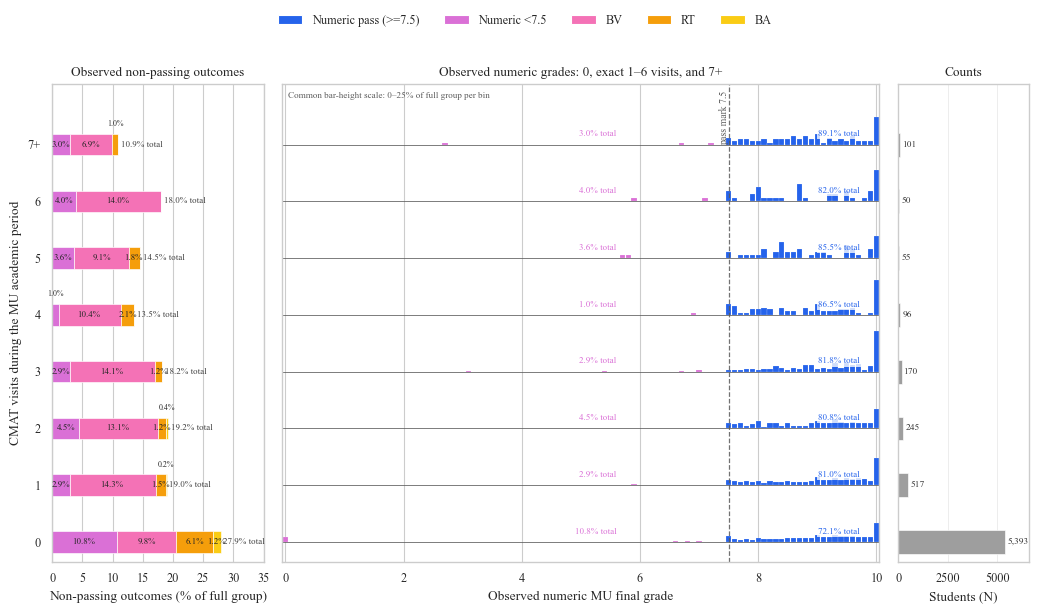

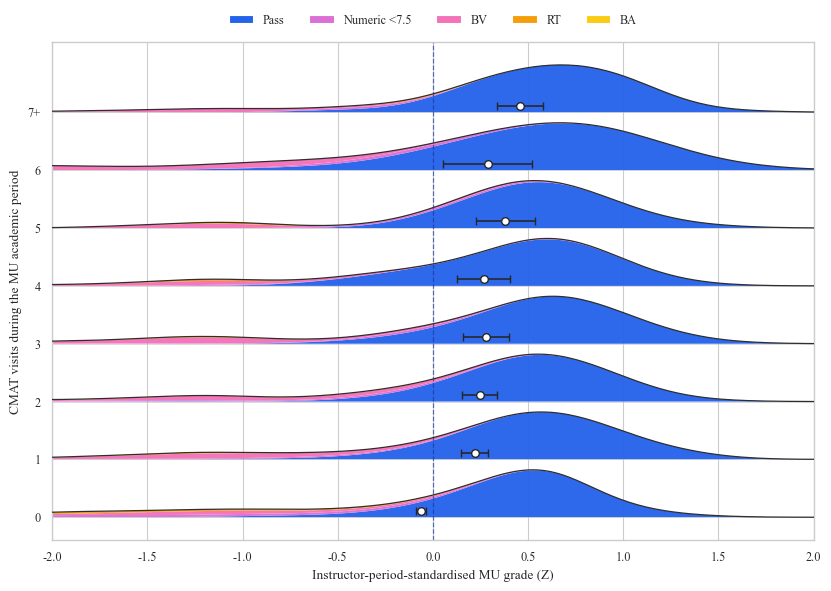

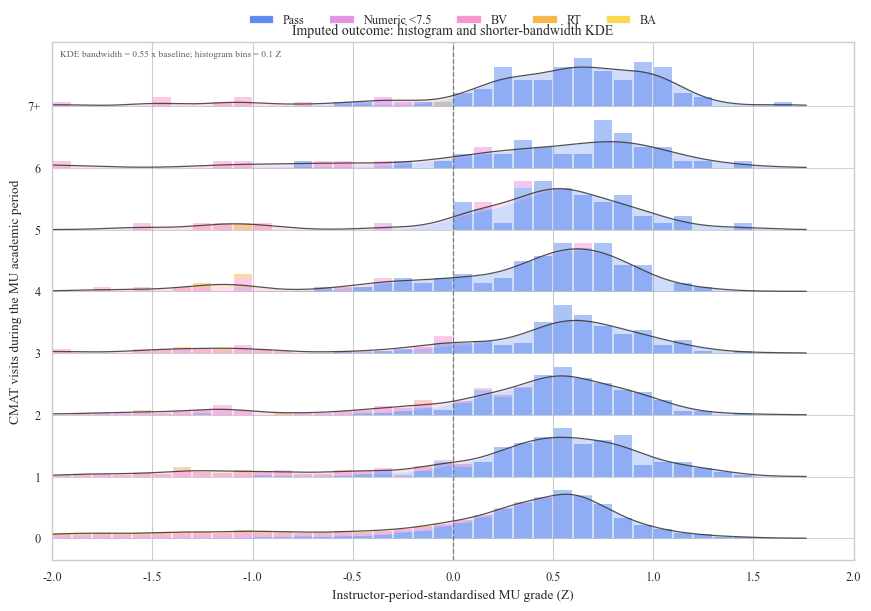

In [34]:
# Figure 1a: observed numeric grades and non-passing outcomes before imputation.
render_paper_figure(paper21_figures.plot_observed_pre_imputation_structure)


# Figure 1: completed standardized outcome and outcome-state composition.
render_paper_figure(paper21_figures.plot_distribution_and_composition)

# Figure 2 diagnostic: 0.1-Z histogram plus a 0.55x-bandwidth KDE,
# including the imputed BV/RT/BA values in their publication colours.
render_paper_figure(paper21_figures.plot_imputed_histogram_kde_overlay)


## 6. Primary benchmark: zero visits versus any attendance

The first estimand deliberately collapses all positive attendance into one group. This isolates **entry into the support system** from the later question of visit frequency among users.

The benchmark estimated in Section 6.1 is an OLS regression that compares zero visits with any recorded attendance while including instructor-period fixed effects and degree-programme indicators; its covariance matrix is clustered by instructor-period. For the continuous outcome, the attendance contrast is expressed in within-instructor-period standard-deviation units. For PASS, the same regression is used as a linear-probability model, so the attendance contrast is an adjusted probability difference that can be reported in percentage points.


### 6.1 Benchmark model: zero visits versus any recorded attendance

#### What this block does

This block creates a binary exposure $\mathbb 1(K_i>0)$ and fits the paper's primary benchmark twice: once with `Z_GRADE_PRIMARY` as the outcome and once with PASS as the outcome.

#### What is happening mathematically / technically?

The call to `fixed_effect_group_comparisons()` constructs the exact statsmodels formula

$$
Y_i
=
\beta_0
+\beta_A A_i
+\sum_{c=2}^{C}\alpha_c\,\mathbf 1(C_i=c)
+\sum_{d=2}^{D}\delta_d\,\mathbf 1(D_i=d)
+\varepsilon_i,
$$

where

- $A_i=\mathbf 1(K_i>0)$;
- $C_i$ is `CLASSROOM_ID` = instructor × academic period;
- $D_i$ is `CLAVECARRERA`;
- $Y_i$ is either $Z_i$ or $PASS_i$.

This is implemented as **ordinary least squares with explicit dummy variables**, not as a mixed model and not as a conditional fixed-effects estimator. For PASS, OLS on a 0/1 outcome is the linear probability model (LPM).

The point estimate is the OLS projection

$$
\hat\beta=(X'X)^{-1}X'Y
$$

(up to the generalized-inverse handling used internally for any redundant dummy columns). Uncertainty is replaced by a cluster-robust sandwich covariance at `CLASSROOM_ID`,

$$
\widehat V_{\mathrm{CR}}
\propto
(X'X)^{-1}
\left(
\sum_c X_c'\hat u_c\hat u_c'X_c
\right)
(X'X)^{-1},
$$

with statsmodels' cluster-covariance implementation supplying the finite-sample conventions.

Because the group order is $[0,1+]$, the underlying regression coefficient is parameterized as $1+$ relative to 0, but `fixed_effect_group_comparisons()` reports the requested pair as $\widehat{0-(1+)}$. The wrapper deliberately negates that quantity so the displayed estimand is

$$
\widehat\Delta_{1+,0}
=
\widehat E[Y\mid 1+,X]
-
\widehat E[Y\mid 0,X].
$$

For the standardized continuous outcome, this is measured in within-classroom SD units. For the LPM, it is a probability difference, so multiplying by 100 gives percentage points. The fixed effects and degree indicators adjust observed composition; they do not remove unmeasured selection into CMAT.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

This is ordinary least squares with indicator variables. Each row of $X$ is one student; its columns contain an intercept, the attendance indicator $A_i$, instructor-period dummies, and degree-programme dummies. OLS chooses $\hat\beta$ to minimize

$$
\|Y-X\beta\|^2,
$$

which gives

$$
X^\top X\hat\beta=X^\top Y
$$

and therefore

$$
\hat\beta=(X^\top X)^{-1}X^\top Y
$$

when the inverse exists. The fitted residuals are

$$
\hat u=Y-X\hat\beta.
$$

For the continuous outcome, $Y=Z$. For PASS, $Y$ is 0 or 1, so the same OLS calculation is called a <em>linear probability model</em>; because $E[PASS\mid X]=P(PASS=1\mid X)$, the attendance coefficient is directly a probability difference.

The cluster-robust covariance concerns uncertainty in $\hat\beta$. From

$$
\hat\beta-\beta=A\varepsilon,
\qquad
A=(X^\top X)^{-1}X^\top,
$$

the matrix identity

$$
\operatorname{Var}(A\varepsilon)
=
A\,\operatorname{Var}(\varepsilon)\,A^\top
$$

explains why covariance appears on both sides. The true errors are unobserved, so we use residuals $\hat u$. Grouping them by instructor-period $g$ gives

$$
\widehat V_{\mathrm{CR}}
=
(X^\top X)^{-1}
\left[
\sum_g
X_g^\top
\hat u_g\hat u_g^\top
X_g
\right]
(X^\top X)^{-1}.
$$

Here $\widehat V_{\mathrm{CR}}$ estimates $\operatorname{Var}(\hat\beta)$. Its diagonal entries are estimated coefficient variances, and their square roots are the cluster-robust standard errors. The matrix $\hat u_g\hat u_g^\top$ allows residuals from students in the same instructor-period to move together rather than forcing within-cluster independence.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The mean model uses OLS with indicator variables for attendance, instructor-period, and degree programme. For the cluster-robust covariance we explicitly do <em>not</em> assume one common residual variance for every student: residual variance may differ across observations, and residuals may be arbitrarily correlated within the same instructor-period cluster. The key remaining dependence assumption is that different clusters are approximately independent for the sandwich approximation, with enough clusters for asymptotic inference to be reasonable.

This robustness concerns standard errors, not confounding. Clustering does not make $A_i$ exogenous, does not correct omitted variables, and does not turn the association into a causal effect. Instructor-period fixed effects absorb additive context-level differences, but they cannot remove unobserved differences between attending and non-attending students within the same context.

We choose this benchmark because its estimand is transparent: one adjusted difference between 0 visits and any attendance. For PASS, the same specification is used as a linear probability model because the coefficient is directly a probability difference in percentage points. Its known limitation is that fitted values can fall outside $[0,1]$; we therefore also fit a logit as a nonlinear sensitivity rather than pretending the LPM is the only possible binary-outcome model.

</div>


In [35]:
benchmark_data = mu.copy()
benchmark_data["ATTENDANCE_BINARY"] = np.where(
    benchmark_data["VISITS_CMAT_PERIOD"].gt(0), "1+", "0"
)

def run_binary_benchmark(outcome_col, title):
    pairwise, omnibus, info = fixed_effect_group_comparisons(
        benchmark_data,
        group_col="ATTENDANCE_BINARY",
        group_order=["0", "1+"],
        outcome_col=outcome_col,
        fixed_effect_col="CLASSROOM_ID",
        cluster_col="CLASSROOM_ID",
        categorical_covariates=["CLAVECARRERA"],
        multiplicity_method="holm",
    )

    model, d, formula = fit_full_ols_group_model(
        benchmark_data,
        group_col="ATTENDANCE_BINARY",
        group_order=["0", "1+"],
        outcome_col=outcome_col,
        cluster_col="CLASSROOM_ID",
    )
    if not SUMMARY:
        display_full_model(
            model, d, formula,
            cluster_col="CLASSROOM_ID",
            title=title,
        )
        display(Markdown(f"#### {title} — pairwise contrast"))
        display(pairwise)
        display(Markdown(f"#### {title} — omnibus test"))
        display(omnibus)
        display(Markdown(f"#### {title} — compact model information"))
        display(info)

    row = pairwise.iloc[0]
    return {
        "outcome": outcome_col,
        "1+ minus 0": -float(row["estimate_group1_minus_group2"]),
        "cluster_robust_se": float(row["cluster_robust_se"]),
        "ci95_low": -float(row["ci_high"]),
        "ci95_high": -float(row["ci_low"]),
        "p_value": float(row["p_raw"]),
        "N": int(row["n"]),
        "clusters": int(info.loc[0, "n_clusters"]),
    }

benchmark = pd.DataFrame([
    run_binary_benchmark(
        "Z_GRADE_PRIMARY",
        "Continuous standardized grade: any attendance vs zero",
    ),
    run_binary_benchmark(
        "PASS",
        "PASS linear-probability model: any attendance vs zero",
    ),
])

display(Markdown("#### Compact benchmark table used in the manuscript"))
display(benchmark)



#### Compact benchmark table used in the manuscript

,outcome,1+ minus 0,cluster_robust_se,ci95_low,ci95_high,p_value,N,clusters
0,Z_GRADE_PRIMARY,0.3612,0.0303,0.3017,0.4207,0.0000,6627,190
1,PASS,0.1529,0.0146,0.1244,0.1815,0.0000,6627,190


The central benchmark is large: any recorded attendance is associated with approximately **+0.361 SD** in standardized final performance and **+15.3 percentage points** in pass probability. These are adjusted associations, not causal treatment effects.

Formally, the fitted comparison can be written schematically as

$$
Y_i=\alpha+\beta\,\mathbb{1}(\mathrm{CMAT}_i>0)
+\gamma_{\mathrm{instructor}\times\mathrm{period}}
+\delta_{\mathrm{degree}}+\varepsilon_i.
$$

The coefficient $\beta$ describes an adjusted difference in observed outcomes. Because CMAT use is selected rather than randomized, it is not automatically equal to a causal potential-outcome contrast.


## 7. Frequency among users and the PPA threshold

The next question is whether outcomes form a staircase across 0, 1, 2, ..., 7+ visits. All 28 pairwise comparisons in the eight-group family are estimated with instructor-period fixed effects, degree-programme adjustment, cluster-robust uncertainty, and Holm correction for multiple testing.

The third visit receives special attention because it is the institutional PPA threshold, but an institutional threshold need not be an academic performance threshold.


### 7.1 Eight-group fixed-effect model and the full pairwise contrast family

#### What this block does

This block replaces the binary attendance indicator with the complete reporting factor `0/1/2/3/4/5/6/7+` and fits the same adjusted model separately for standardized performance and PASS.

#### What is happening mathematically / technically?

With 0 as the treatment reference, the fitted OLS model is

$$
Y_i
=
\beta_0
+\sum_{k\in\{1,2,3,4,5,6,7+\}}
\beta_k\,\mathbf 1(K_i=k)
+\sum_{c=2}^{C}\alpha_c\mathbf 1(C_i=c)
+\sum_{d=2}^{D}\delta_d\mathbf 1(D_i=d)
+\varepsilon_i.
$$

Again, PASS is fit as an LPM; the continuous outcome uses the same design matrix. Cluster-robust covariance is computed by `CLASSROOM_ID`.

For any two groups $k$ and $j$, the code creates a contrast vector $a_{kj}$ and asks statsmodels for

$$
\widehat\Delta_{kj}
=
a_{kj}'\hat\beta,
\qquad
SE(\widehat\Delta_{kj})
=
\sqrt{a_{kj}'\widehat V_{\mathrm{CR}}a_{kj}}.
$$

If neither group is the reference, this is algebraically $\hat\beta_k-\hat\beta_j$. With eight groups there are

$$
\binom{8}{2}=28
$$

pairwise tests.

The omnibus test is the joint null

$$
H_0:
\beta_1=\beta_2=\cdots=\beta_{7+}=0,
$$

implemented by `model.f_test(R\beta=0)` using the fitted covariance structure.

Finally, the 28 raw pairwise $p$-values are adjusted using Holm's step-down family-wise-error procedure. If $p_{(1)}\le\cdots\le p_{(m)}$, Holm sequentially compares $p_{(r)}$ with $\alpha/(m-r+1)$. This is why a locally small raw $p$-value need not remain significant after the full comparison family is acknowledged.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

Although this is called a linear model, visit count is not entered as the number 0,1,2,... with one common slope. Each attendance category receives its own indicator column. With 0 visits as the reference,

$$
E[Y_i\mid X_i]
=
\beta_0
+
\beta_1I(K_i=1)
+\cdots+
\beta_{7+}I(K_i=7+)
+\text{fixed effects}
+\text{degree indicators}.
$$

The model is therefore linear in the unknown coefficients, but the attendance-outcome relationship can have any shape. There is no requirement that $\beta_2=2\beta_1$ or that adjacent increments be equal.

A pairwise comparison is a linear combination of coefficients. For example,

$$
\mu_3-\mu_2
=
\beta_3-\beta_2.
$$

If the contrast is written as $a^\top\hat\beta$, then

$$
\operatorname{Var}(a^\top\hat\beta)
=
a^\top\widehat V_{\mathrm{CR}}a,
$$

so its standard error is the square root of that scalar. Eight groups produce 28 distinct unordered pairs.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The crucial modeling choice is to treat attendance frequency as a categorical factor rather than as a single numeric slope. We therefore do <em>not</em> assume that the effect of one additional visit is constant, linear, monotone, or even positive. Each frequency group receives its own coefficient, so the observed pattern may rise, flatten, or reverse. This flexibility costs precision because more parameters are estimated, which is why the high-frequency support audit matters.

The same cluster-robust assumptions as in Section 6 apply: heteroskedasticity across students is allowed, arbitrary residual covariance is allowed within instructor-period, and approximate independence is required across clusters. Holm correction is chosen because all pairwise comparisons belong to one planned family and we want family-wise error control rather than interpreting unadjusted $p$-values one at a time.

</div>


In [36]:
z_pair, z_omnibus, z_info = fixed_effect_group_comparisons(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="Z_GRADE_PRIMARY",
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=["CLAVECARRERA"],
    multiplicity_method="holm",
)

pass_pair, pass_omnibus, pass_info = fixed_effect_group_comparisons(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="PASS",
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=["CLAVECARRERA"],
    multiplicity_method="holm",
)

z_model, z_model_data, z_formula = fit_full_ols_group_model(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="Z_GRADE_PRIMARY",
    cluster_col="CLASSROOM_ID",
)
pass_lpm_model, pass_lpm_data, pass_lpm_formula = fit_full_ols_group_model(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="PASS",
    cluster_col="CLASSROOM_ID",
)

if SUMMARY:
    display_full_model(
        z_model, z_model_data, z_formula,
        cluster_col="CLASSROOM_ID",
        title="Eight-group continuous-outcome OLS",
    )
    display(Markdown("#### Continuous outcome — omnibus test"))
    display(z_omnibus)

    display_full_model(
        pass_lpm_model, pass_lpm_data, pass_lpm_formula,
        cluster_col="CLASSROOM_ID",
        title="Eight-group PASS linear-probability model",
    )
    display(Markdown("#### PASS LPM — omnibus test"))
    display(pass_omnibus)
else:
    display_full_model(
        z_model, z_model_data, z_formula,
        cluster_col="CLASSROOM_ID",
        title="Eight-group continuous-outcome OLS",
    )
    display(Markdown("#### Continuous outcome — all 28 pairwise contrasts"))
    display(z_pair)
    display(Markdown("#### Continuous outcome — omnibus test"))
    display(z_omnibus)
    display(Markdown("#### Continuous outcome — compact model information"))
    display(z_info)

    display_full_model(
        pass_lpm_model, pass_lpm_data, pass_lpm_formula,
        cluster_col="CLASSROOM_ID",
        title="Eight-group PASS linear-probability model",
    )
    display(Markdown("#### PASS LPM — all 28 pairwise contrasts"))
    display(pass_pair)
    display(Markdown("#### PASS LPM — omnibus test"))
    display(pass_omnibus)
    display(Markdown("#### PASS LPM — compact model information"))
    display(pass_info)


#### Eight-group continuous-outcome OLS — compact model summary

,N,covariance_type,cluster_variable,n_clusters,R_squared,adjusted_R_squared,AIC
0,6627,cluster,CLASSROOM_ID,190,0.0582,0.0179,18762.2656


,term,estimate,cluster_robust_se,statistic,p_value,ci95_low,ci95_high
0,Intercept,-0.8649,0.9222,-0.9379,0.3483,-2.6724,0.9425
1,"C(P21_GROUP_7P, Treatment(reference='0'))[T.1]",0.3053,0.0427,7.1572,0.0000,0.2217,0.3889
2,"C(P21_GROUP_7P, Treatment(reference='0'))[T.2]",0.3598,0.0498,7.2217,0.0000,0.2622,0.4575
3,"C(P21_GROUP_7P, Treatment(reference='0'))[T.3]",0.3731,0.0640,5.8273,0.0000,0.2476,0.4986
4,"C(P21_GROUP_7P, Treatment(reference='0'))[T.4]",0.3562,0.0862,4.1340,0.0000,0.1873,0.5250
5,"C(P21_GROUP_7P, Treatment(reference='0'))[T.5]",0.5302,0.0941,5.6349,0.0000,0.3458,0.7146
6,"C(P21_GROUP_7P, Treatment(reference='0'))[T.6]",0.4132,0.1332,3.1031,0.0019,0.1522,0.6742
7,"C(P21_GROUP_7P, Treatment(reference='0'))[T.7+]",0.5493,0.0773,7.1108,0.0000,0.3979,0.7007


#### Continuous outcome — omnibus test

,null_hypothesis,test_statistic,df_num,p_value,n,n_clusters
0,equal adjusted outcomes across listed groups,23.9758,7,0.0000,6627,190


#### Eight-group PASS linear-probability model — compact model summary

,N,covariance_type,cluster_variable,n_clusters,R_squared,adjusted_R_squared,AIC
0,6627,cluster,CLASSROOM_ID,190,0.1718,0.1364,7175.7372


,term,estimate,cluster_robust_se,statistic,p_value,ci95_low,ci95_high
0,Intercept,0.4862,0.2279,2.1335,0.0329,0.0396,0.9329
1,"C(P21_GROUP_7P, Treatment(reference='0'))[T.1]",0.1213,0.0190,6.3892,0.0000,0.0841,0.1585
2,"C(P21_GROUP_7P, Treatment(reference='0'))[T.2]",0.1463,0.0264,5.5441,0.0000,0.0946,0.1981
3,"C(P21_GROUP_7P, Treatment(reference='0'))[T.3]",0.1424,0.0325,4.3827,0.0000,0.0787,0.2060
4,"C(P21_GROUP_7P, Treatment(reference='0'))[T.4]",0.1939,0.0407,4.7697,0.0000,0.1142,0.2736
5,"C(P21_GROUP_7P, Treatment(reference='0'))[T.5]",0.2179,0.0504,4.3236,0.0000,0.1191,0.3167
6,"C(P21_GROUP_7P, Treatment(reference='0'))[T.6]",0.2046,0.0640,3.1994,0.0014,0.0793,0.3300
7,"C(P21_GROUP_7P, Treatment(reference='0'))[T.7+]",0.2662,0.0383,6.9505,0.0000,0.1911,0.3412


#### PASS LPM — omnibus test

,null_hypothesis,test_statistic,df_num,p_value,n,n_clusters
0,equal adjusted outcomes across listed groups,18.9559,7,0.0000,6627,190


### 7.2 Extraction of pre-interpreted contrasts from the fitted family

#### What this block does

This helper retrieves specific rows from the already fitted 28-comparison table: 2 vs 3, 4 vs 5, and 6 vs 7+.

#### What is happening mathematically / technically?

No model is estimated here. The function only searches the long-format contrast table while allowing either orientation $(k,j)$ or $(j,k)$.

This distinction matters because the scientific interpretation is attached to particular linear hypotheses:

$$
H_0^{PPA}:\mu_2-\mu_3=0,
$$

$$
H_0^{4\rightarrow5}:\mu_4-\mu_5=0,
\qquad
H_0^{6\rightarrow7+}:\mu_6-\mu_{7+}=0.
$$

The estimates, cluster-robust standard errors, confidence intervals, raw $p$-values, and Holm-adjusted $p$-values all come from the single model fitted in the previous block. This cell merely exposes the contrasts that are substantively relevant to the PPA and high-frequency hypotheses.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

No new regression is fitted here. The previous model already contains enough information to compute every pairwise difference. If the stored coefficient vector is $\hat\beta$, a contrast vector $a$ with $+1$ for one group, $-1$ for another, and 0 elsewhere extracts

$$
\widehat\Delta
=
a^\top\hat\beta.
$$

Its uncertainty comes from the same coefficient covariance matrix:

$$
SE(\widehat\Delta)
=
\sqrt{
a^\top\widehat V_{\mathrm{CR}}a
}.
$$

This is the matrix version of the familiar scalar rule for the variance of a linear combination. The code cell therefore does not “search again” in the data; it only selects scientifically relevant linear combinations from the already fitted 28-comparison family.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

These contrasts inherit every assumption of the model fitted in Section 7.1; extracting a row does not create a new model or a new source of independence. The sign of a contrast depends on the order in which groups are subtracted, so the notebook states the direction explicitly rather than relying on coefficient names. We choose linear contrasts because they answer the substantive questions directly while preserving one common fitted model and one common covariance matrix for the full comparison family.

</div>


In [37]:
def get_pair(frame, a, b):
    hit = frame.loc[
        ((frame["group1"].astype(str) == str(a)) & (frame["group2"].astype(str) == str(b))) |
        ((frame["group1"].astype(str) == str(b)) & (frame["group2"].astype(str) == str(a)))
    ].copy()
    if hit.empty:
        raise KeyError(f"Pair {a} vs {b} not found")
    return hit

display(Markdown("### PPA threshold: 2 versus 3 visits"))
display(get_pair(z_pair, "2", "3"))

display(Markdown("### Descriptive later changes: 4 versus 5 and 6 versus 7+"))
display(pd.concat([
    get_pair(z_pair, "4", "5"),
    get_pair(z_pair, "6", "7+"),
], ignore_index=True))


### PPA threshold: 2 versus 3 visits

,group1,group2,estimate_group1_minus_group2,cluster_robust_se,ci_low,ci_high,p_raw,adjacent_groups,p_adjusted,reject_adjusted,n,n_clusters
13,2,3,-0.0133,0.0671,-0.1449,0.1183,0.8433,True,1.0000,False,6627,190


### Descriptive later changes: 4 versus 5 and 6 versus 7+

,group1,group2,estimate_group1_minus_group2,cluster_robust_se,ci_low,ci_high,p_raw,adjacent_groups,p_adjusted,reject_adjusted,n,n_clusters
0,4,5,-0.1740,0.1127,-0.3949,0.0468,0.1224,True,1.0000,False,6627,190
1,6,7+,-0.1361,0.1499,-0.4299,0.1577,0.3639,True,1.0000,False,6627,190


The two-versus-three contrast is extremely small and statistically unresolved, so the third visit is not an observable performance discontinuity. The visually noticeable increases from four to five visits and from six to 7+ are also not statistically resolved after accounting for uncertainty and multiplicity.

This produces a central distinction:

$$
\text{institutional threshold at 3 visits}
\neq
\text{demonstrated academic threshold at 3 visits}.
$$

Likewise, visible changes later in the sequence should be described as **descriptive profile changes**, not causal jumps.


## 8. Why 7+ is nevertheless distinctive

The 7+ group has the highest descriptive mean standardized outcome and the highest observed pass rate. The binary PASS analysis provides stronger within-user evidence than the continuous outcome: the adjusted pass probability for 7+ exceeds the one-visit group by about 14.5 percentage points after Holm correction.

The manuscript also reports fixed-effect logistic **odds-ratio point estimates** for magnitude. Because the full logistic clustered covariance is rank-deficient in this design, multiplicity-aware PASS inference comes from the stable linear-probability model, while logistic odds ratios are treated as descriptive effect-size estimates.


### 8.1 High-frequency PASS: LPM inference and fixed-effect logit odds ratios

#### What this block does

This block first displays the 1 vs 7+ PASS contrast from the LPM fitted above, then fits a separate binomial-logit model to express pairwise differences on the odds-ratio scale.

#### What is happening mathematically / technically?

The logistic specification is

$$
\log\frac{P(PASS_i=1\mid X_i)}
{1-P(PASS_i=1\mid X_i)}
=
\beta_0
+\sum_k\beta_k\mathbf 1(K_i=k)
+\sum_c\alpha_c\mathbf 1(C_i=c)
+\sum_d\delta_d\mathbf 1(D_i=d).
$$

In code this is `statsmodels.glm(..., family=Binomial())` with the same explicit fixed-effect dummies and cluster-robust covariance by `CLASSROOM_ID`. The GLM coefficients are estimated by the numerical fitting routine used by statsmodels for the binomial likelihood; they are not conditional-logit fixed effects.

For a pair $k,j$,

$$
\widehat{\log OR}_{kj}
=
a_{kj}'\hat\beta,
\qquad
\widehat{OR}_{kj}
=
\exp(a_{kj}'\hat\beta).
$$

Thus the reported OR is a **conditional model odds ratio**, not a risk ratio and not the same estimand as the LPM percentage-point contrast.

A technical problem arises in the omnibus clustered logit covariance: with many fixed-effect dummies and sparse high-frequency cells, the restricted covariance can be rank-deficient. The library therefore computes the omnibus Wald statistic with a Moore-Penrose inverse,

$$
W=(R\hat\beta)'
(R\widehat V R')^{+}
(R\hat\beta),
$$

and uses $\mathrm{rank}(R\widehat V R')$ as the chi-square degrees of freedom. Because this covariance issue makes multiplicity-aware logistic inference less stable, Paper 2.1 uses the LPM pairwise tests for PASS significance and retains logit primarily for OR effect-size description.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

The LPM works on the probability scale directly. Logistic regression instead assumes

$$
p_i
=
P(PASS_i=1\mid X_i)
=
\frac{1}{1+e^{-X_i^\top\beta}},
$$

which is equivalent to

$$
\log\!\left(
\frac{p_i}{1-p_i}
\right)
=
X_i^\top\beta.
$$

Because PASS is Bernoulli, observation $i$ contributes

$$
p_i^{y_i}(1-p_i)^{1-y_i}
$$

to the likelihood, so the full likelihood is the product of those terms. Logistic regression chooses the coefficient vector that maximizes this likelihood. Unlike OLS, there is no closed-form solution such as $(X^\top X)^{-1}X^\top Y$, so the coefficients are obtained numerically.

If two attendance groups differ by $\Delta$ on the log-odds scale, then

$$
OR=e^\Delta.
$$

An odds ratio of 2 means the odds are doubled; it does not mean the probability is doubled. This is why the LPM and logit can be used together: the LPM gives directly interpretable percentage-point differences, while logit provides a nonlinear sensitivity and odds-ratio scale.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The binomial logit assumes that the conditional log-odds of PASS are additive in the included attendance indicators, instructor-period dummies, and degree-programme indicators. It also requires enough outcome variation to avoid complete or quasi-complete separation; sparse high-frequency cells can make coefficients or covariance estimates unstable. The clustered covariance again allows heteroskedasticity and within-cluster dependence but relies on approximate independence across clusters.

We do not choose logit because it is automatically “more correct” than the LPM. We use it because PASS is binary and logit guarantees fitted probabilities in $[0,1]$ while providing odds ratios. The LPM remains the primary pairwise inferential scale because percentage-point differences are easier to interpret and, in this dataset, its clustered pairwise covariance is more stable than the high-dimensional fixed-effect logit covariance. The implication is that odds ratios are treated as complementary effect-size descriptions, not as the sole source of significance claims.

</div>


In [38]:
display(Markdown("#### 1 versus 7+ PASS contrast from the linear-probability model"))
display(get_pair(pass_pair, "1", "7+"))

logit_pair, logit_omnibus, logit_info = fixed_effect_logistic_group_comparisons(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="PASS",
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=["CLAVECARRERA"],
    multiplicity_method="holm",
)

pass_logit_model, pass_logit_data, pass_logit_formula = fit_full_logit_group_model(
    mu,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="PASS",
    cluster_col="CLASSROOM_ID",
)

if SUMMARY:
    display_full_model(
        pass_logit_model, pass_logit_data, pass_logit_formula,
        cluster_col="CLASSROOM_ID",
        title="Eight-group PASS binomial-logit model",
        exponentiate=True,
    )
    display(Markdown("#### PASS logit — omnibus Wald test"))
    display(logit_omnibus)
    display(Markdown("#### PASS logit — 1 versus 7+ contrast"))
    display(get_pair(logit_pair, "1", "7+"))
else:
    display_full_model(
        pass_logit_model, pass_logit_data, pass_logit_formula,
        cluster_col="CLASSROOM_ID",
        title="Eight-group PASS binomial-logit model",
        exponentiate=True,
    )
    display(Markdown("#### PASS logit — all pairwise odds-ratio contrasts"))
    display(logit_pair)
    display(Markdown("#### PASS logit — omnibus Wald test"))
    display(logit_omnibus)
    display(Markdown("#### PASS logit — compact model information"))
    display(logit_info)
    display(Markdown("#### PASS logit — 1 versus 7+ contrast"))
    display(get_pair(logit_pair, "1", "7+"))


#### 1 versus 7+ PASS contrast from the linear-probability model

,group1,group2,estimate_group1_minus_group2,cluster_robust_se,ci_low,ci_high,p_raw,adjacent_groups,p_adjusted,reject_adjusted,n,n_clusters
12,1,7+,-0.1449,0.0438,-0.2307,-0.0591,0.0009,False,0.0206,True,6627,190


/opt/miniconda3/envs/cmat-research/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:257: RuntimeWarning: divide by zero encountered in divide
  return (2 * p - 1) / v ** 2
/opt/miniconda3/envs/cmat-research/lib/python3.14/site-packages/statsmodels/genmod/generalized_linear_model.py:576: RuntimeWarning: invalid value encountered in multiply
  tmp = score_factor * tmp
/opt/miniconda3/envs/cmat-research/lib/python3.14/site-packages/statsmodels/genmod/families/links.py:257: RuntimeWarning: divide by zero encountered in divide
  return (2 * p - 1) / v ** 2
/opt/miniconda3/envs/cmat-research/lib/python3.14/site-packages/statsmodels/genmod/generalized_linear_model.py:576: RuntimeWarning: invalid value encountered in multiply
  tmp = score_factor * tmp


#### Eight-group PASS binomial-logit model — compact model summary

,N,covariance_type,cluster_variable,n_clusters,AIC,converged
0,6627,cluster,CLASSROOM_ID,190,6922.1774,True


,term,estimate,cluster_robust_se,statistic,p_value,ci95_low,ci95_high,odds_ratio,or_ci95_low,or_ci95_high
0,Intercept,-0.5278,NaN,NaN,NaN,NaN,NaN,0.5899,NaN,NaN
1,"C(P21_GROUP_7P, Treatment(reference='0'))[T.1]",0.7881,NaN,NaN,NaN,NaN,NaN,2.1992,NaN,NaN
2,"C(P21_GROUP_7P, Treatment(reference='0'))[T.2]",0.9196,NaN,NaN,NaN,NaN,NaN,2.5083,NaN,NaN
3,"C(P21_GROUP_7P, Treatment(reference='0'))[T.3]",0.9075,NaN,NaN,NaN,NaN,NaN,2.4780,NaN,NaN
4,"C(P21_GROUP_7P, Treatment(reference='0'))[T.4]",1.3131,NaN,NaN,NaN,NaN,NaN,3.7176,NaN,NaN
5,"C(P21_GROUP_7P, Treatment(reference='0'))[T.5]",1.4589,NaN,NaN,NaN,NaN,NaN,4.3013,NaN,NaN
6,"C(P21_GROUP_7P, Treatment(reference='0'))[T.6]",1.1813,NaN,NaN,NaN,NaN,NaN,3.2587,NaN,NaN
7,"C(P21_GROUP_7P, Treatment(reference='0'))[T.7+]",1.8001,NaN,NaN,NaN,NaN,NaN,6.0502,NaN,NaN


#### PASS logit — omnibus Wald test

,null_hypothesis,test_statistic,df_num,p_value,n,n_clusters
0,equal adjusted log odds across listed groups,NaN,0,NaN,6627,190


#### PASS logit — 1 versus 7+ contrast

,group1,group2,log_odds_difference_group1_minus_group2,odds_ratio_group1_vs_group2,cluster_robust_se_log_odds,or_ci_low,or_ci_high,p_raw,adjacent_groups,p_adjusted,reject_adjusted,n,n_clusters
12,1,7+,-1.0120,0.3635,NaN,NaN,NaN,NaN,False,NaN,True,6627,190


### 8.2 Pairwise effect and multiplicity dashboards

#### What this block does

The plotting functions reorganize the long-format pairwise output into symmetric $8\times8$ matrices and render effect sizes, raw $p$-values, and Holm-adjusted $p$-values.

#### What is happening mathematically / technically?

For the continuous outcome, matrix entry $(k,j)$ contains

$$
M^{Z}_{kj}=\widehat\Delta_{kj},
\qquad
M^{Z}_{jk}=-M^{Z}_{kj}.
$$

For PASS odds ratios,

$$
M^{OR}_{kj}=\widehat{OR}_{kj},
\qquad
M^{OR}_{jk}=1/\widehat{OR}_{kj}.
$$

The plotting code log-transforms the OR matrix for a color scale centered symmetrically at the null because

$$
\log(OR_{jk})=-\log(OR_{kj}),
$$

while it prints the OR itself as the cell annotation.

The $p$-value matrices are symmetric because the two-sided test of $k-j=0$ is identical to that of $j-k=0$. Raw and Holm-adjusted values are displayed separately so magnitude, local evidence, and family-wise inference are not conflated.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

The dashboard reorganizes already computed pairwise results into a matrix. Additive contrasts satisfy

$$
\Delta_{jk}
=
-\Delta_{kj},
$$

while odds ratios satisfy

$$
OR_{jk}
=
\frac{1}{OR_{kj}}.
$$

The multiplicity issue arises because 28 hypotheses are inspected at once. Even if every null hypothesis were true, testing each one at 5% would make at least one false positive much more likely than 5%. Holm's method first orders the raw $p$-values,

$$
p_{(1)}\le p_{(2)}\le\cdots\le p_{(m)},
$$

then compares them sequentially with increasingly less strict thresholds. This controls the probability of making one or more false rejections across the entire family, while usually being less conservative than a simple Bonferroni correction applied identically to every comparison.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The dashboard assumes that the underlying pairwise statistics and their covariance estimates are valid; visualization does not repair a weak model. Holm correction controls the family-wise error rate across the declared family of comparisons, but it does not remove model misspecification, selection bias, or sparse-cell uncertainty. We choose Holm because it is a strong-error-rate procedure that is uniformly at least as powerful as simple Bonferroni while remaining valid under general dependence among tests.

</div>


/Users/heri/git/CMAT/CMAT-research/code/figures_paper21.py:585: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar_right.set_ticklabels([f"{np.exp(value):.2f}" for value in ticks])


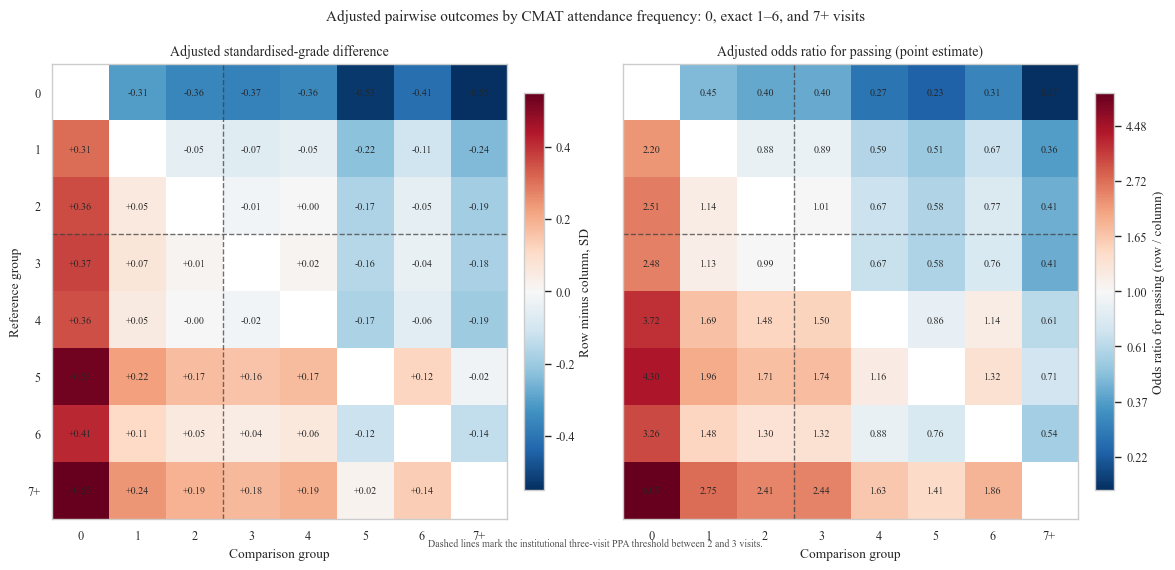

/var/folders/b6/xfpsjq5131b_js2wwdjdcd0w0000gn/T/ipykernel_85513/3703217992.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


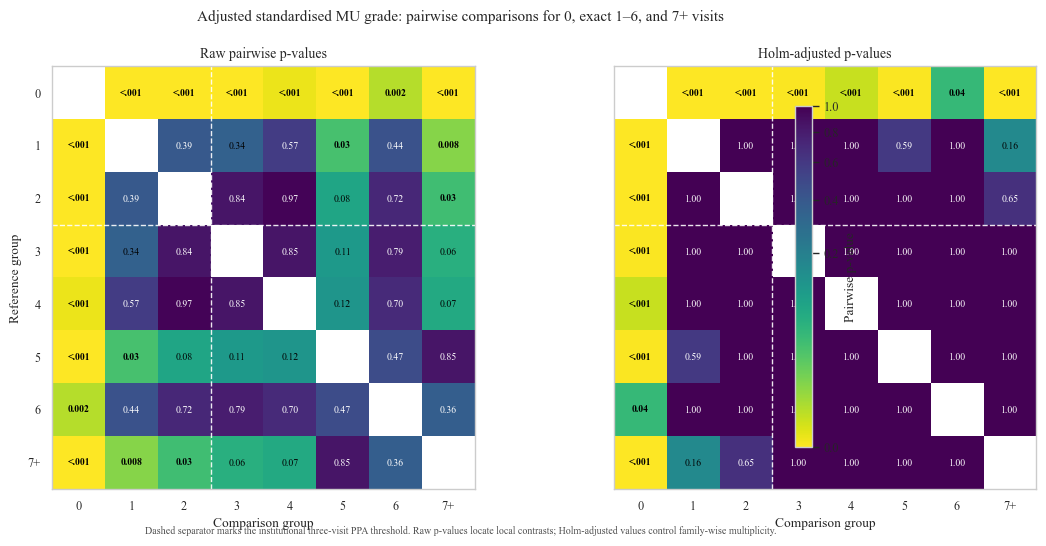

/var/folders/b6/xfpsjq5131b_js2wwdjdcd0w0000gn/T/ipykernel_85513/3703217992.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


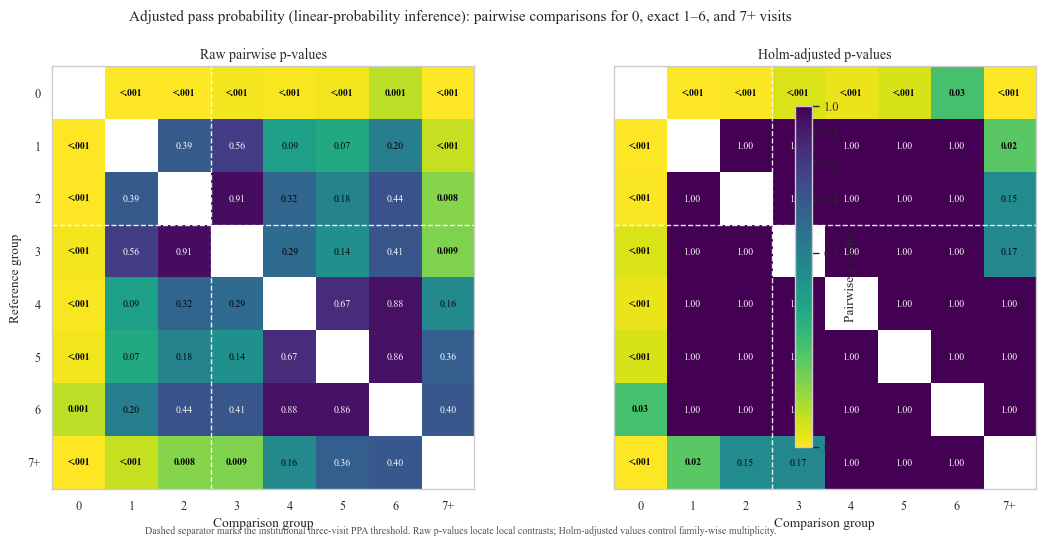

In [39]:
# Pairwise adjusted effect dashboard.
render_paper_figure(paper21_figures.plot_pairwise_effect_dashboard)

# Raw and Holm-adjusted pairwise p-value dashboards.
render_paper_figure(paper21_figures.plot_z_pvalue_dashboard)
render_paper_figure(paper21_figures.plot_pass_pvalue_dashboard)


The evidence therefore supports describing 7+ as a **distinctive high-frequency profile**, especially for PASS. It does not support the stronger claim that a causal threshold begins at the seventh visit, because the adjacent exact-six versus 7+ comparison is itself imprecise.


## 9. Adverse outcomes are not interchangeable

PASS/non-PASS hides substantively different endpoints. A non-passing attempt may end as:

- a completed numeric grade below 7.5,
- BV (voluntary withdrawal),
- RT (temporary withdrawal),
- BA (academic withdrawal).

The paper therefore distinguishes a **performance margin** from an **academic-management margin**. The second asks, conditional on not passing, how the adverse outcome is recorded.


### 9.1 Five-state decomposition of the final academic record

#### What this block does

This block replaces the binary PASS/non-PASS summary with the exact five-state outcome: PASS, numeric grade below 7.5, BV, RT, and BA.

#### What is happening mathematically / technically?

For each attendance group $k$ and outcome state $s$, the code estimates the empirical multinomial cell probability

$$
\hat p_{ks}
=
\frac{n_{ks}}{n_k},
\qquad
\sum_s\hat p_{ks}=1.
$$

No multinomial regression is fitted in this block. It is a direct contingency-table decomposition using the exact administrative token preserved by `add_academic_outcome_states()`.

The distinction is essential because two groups can have the same

$$
P(nonPASS\mid K=k)
$$

while having different conditional compositions

$$
P(S=s\mid nonPASS,K=k).
$$

The next block moves from this unconditional state composition to explicit binary contrasts within the non-PASS subset.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

This is a contingency-table calculation, not a regression. If $n_{ks}$ students in attendance group $k$ end in state $s$, then

$$
\hat p_{ks}
=
\frac{n_{ks}}{n_k},
\qquad
\sum_s\hat p_{ks}=1.
$$

The five probabilities partition the entire attendance group. Collapsing them to PASS/non-PASS computes

$$
P(nonPASS\mid K=k)
=
1-P(PASS\mid K=k),
$$

but that binary collapse discards information about whether non-PASS means a numeric grade below 7.5, BV, RT, or BA. The purpose of this block is therefore to show where the non-PASS probability mass is located before any conditional regression is imposed.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

This block makes almost no parametric distributional assumption: it treats the observed final states as mutually exclusive categories and estimates their empirical proportions. The important substantive assumption is classificatory—PASS, numeric failure, BV, RT, and BA are being treated as distinct outcome states whose administrative meanings are preserved. We choose this decomposition because a binary PASS indicator can hide very different mechanisms inside non-PASS. The implication is descriptive only: different state shares do not identify why students ended in those states.

</div>


In [40]:
composition = (
    mu.groupby(["P21_GROUP_7P", "ACADEMIC_OUTCOME_STATE_5"], observed=True)
      .size()
      .rename("n")
      .reset_index()
)
composition["share"] = composition.groupby("P21_GROUP_7P")["n"].transform(lambda s: s / s.sum())
composition_pivot = composition.pivot(
    index="P21_GROUP_7P", columns="ACADEMIC_OUTCOME_STATE_5", values="share"
).reindex(GROUP_ORDER).fillna(0)

composition_pivot


ACADEMIC_OUTCOME_STATE_5,BA,BV,RT,numeric_nonpass,pass
P21_GROUP_7P,,,,,
0,0.0124,0.0977,0.0610,0.1077,0.7211
1,0.0019,0.1431,0.0155,0.0290,0.8104
2,0.0041,0.1306,0.0122,0.0449,0.8082
3,0.0000,0.1412,0.0118,0.0294,0.8176
4,0.0000,0.1042,0.0208,0.0104,0.8646
5,0.0000,0.0909,0.0182,0.0364,0.8545
6,0.0000,0.1400,0.0000,0.0400,0.8200
7+,0.0000,0.0693,0.0099,0.0297,0.8911


### 9.2 Conditional academic-management contrasts among non-PASS observations

#### What this block does

This block restricts the analysis to $PASS=0$ and estimates whether the **type** of adverse ending differs between zero attendance and any attendance.

#### What is happening mathematically / technically?

`add_academic_outcome_states()` creates each contrast with deliberate missingness. For example,

$$
BV\_VS\_NUMERIC_i=
\begin{cases}
1,&S_i=BV,\\
0,&S_i=\text{numeric non-pass},\\
NA,&S_i\in\{RT,BA\}.
\end{cases}
$$

Therefore, when `fixed_effect_group_comparisons()` drops missing model rows, the BV model is fitted **only** to BV and numeric-failure observations. The RT comparison analogously excludes BV and BA. The broad administrative contrast codes BV/RT/BA as 1 and numeric failure as 0.

For each binary contrast $M_i$, the fitted model is an LPM,

$$
M_i
=
\beta_0+\beta_A A_i
+\alpha_{C_i}
+\delta_{D_i}
+\varepsilon_i,
$$

on the relevant non-PASS comparison set, with cluster-robust covariance by `CLASSROOM_ID`.

Thus $\beta_A$ estimates an adjusted **difference in conditional composition**, e.g.

$$
P(BV\mid BV\text{ or numeric fail},A=1,X)
-
P(BV\mid BV\text{ or numeric fail},A=0,X),
$$

within the linear projection. It is not the probability of BV in the full cohort, and conditioning on non-PASS means it should not be interpreted as a total causal effect of CMAT.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

The denominator changes in this section. For the BV-versus-numeric comparison, for example, the analysis keeps only observations whose final state is BV or numeric failure and defines

$$
M_i
=
\begin{cases}
1,&S_i=BV,\\
0,&S_i=\text{numeric failure}.
\end{cases}
$$

RT and BA are excluded from that particular model rather than being counted as 0. Fitting an LPM to $M_i$ therefore compares

$$
P(BV\mid BV\text{ or numeric failure},A=1,X)
$$

with the corresponding probability for $A=0$. The same construction is repeated for RT and for the broader administrative grouping. Consequently, these coefficients describe the composition of adverse outcomes among selected non-PASS records; they are not unconditional probabilities of BV or RT in the full cohort.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

Conditioning on non-PASS changes the estimand and can introduce selection structure of its own. These models assume that the selected comparison set is the intended population for the question being asked; for example, BV versus numeric failure deliberately excludes RT and BA. Cluster-robust covariance still allows unequal residual variances and arbitrary within instructor-period dependence, but it does not make this conditional comparison causal.

We choose separate binary contrasts instead of forcing all adverse states into one multinomial mechanism because the paper's empirical pattern differs by state, especially BV versus RT. The consequence is that each coefficient has a narrower denominator and must be interpreted as a difference in composition among the retained non-PASS states, not as a full-cohort probability.

</div>


In [41]:
nonpass = mu.loc[mu["PASS"].eq(0)].copy()

MANAGEMENT_OUTCOMES = [
    ("ADMINISTRATIVE_VS_NUMERIC_NONPASS", "Any administrative outcome vs numeric failure"),
    ("BVRT_VS_NUMERIC_NONPASS", "BV/RT vs numeric failure, excluding BA"),
    ("BV_VS_NUMERIC_NONPASS", "BV vs numeric failure, excluding RT/BA"),
    ("RT_VS_NUMERIC_NONPASS", "RT vs numeric failure, excluding BV/BA"),
]

management_rows = []

for outcome_col, title in MANAGEMENT_OUTCOMES:
    x = nonpass.loc[nonpass[outcome_col].notna()].copy()
    x["ATTENDANCE_BINARY"] = np.where(
        x["VISITS_CMAT_PERIOD"].gt(0), "1+", "0"
    )

    pairwise, omnibus, info = fixed_effect_group_comparisons(
        x,
        group_col="ATTENDANCE_BINARY",
        group_order=["0", "1+"],
        outcome_col=outcome_col,
        fixed_effect_col="CLASSROOM_ID",
        cluster_col="CLASSROOM_ID",
        categorical_covariates=["CLAVECARRERA"],
        multiplicity_method="holm",
    )

    model, d, formula = fit_full_ols_group_model(
        x,
        group_col="ATTENDANCE_BINARY",
        group_order=["0", "1+"],
        outcome_col=outcome_col,
        cluster_col="CLASSROOM_ID",
    )

    if not SUMMARY:
        display_full_model(
            model, d, formula,
            cluster_col="CLASSROOM_ID",
            title=title,
        )
        display(Markdown(f"#### {title} — pairwise contrast"))
        display(pairwise)
        display(Markdown(f"#### {title} — omnibus test"))
        display(omnibus)
        display(Markdown(f"#### {title} — compact model information"))
        display(info)

    row = pairwise.iloc[0]
    management_rows.append({
        "contrast": outcome_col,
        "1+ minus 0": -float(row["estimate_group1_minus_group2"]),
        "cluster_robust_se": float(row["cluster_robust_se"]),
        "ci95_low": -float(row["ci_high"]),
        "ci95_high": -float(row["ci_low"]),
        "p_value": float(row["p_raw"]),
        "N": int(row["n"]),
        "clusters": int(info.loc[0, "n_clusters"]),
    })

management = pd.DataFrame(management_rows)
display(Markdown("#### Compact non-PASS management benchmark table"))
display(management)



#### Compact non-PASS management benchmark table

,contrast,1+ minus 0,cluster_robust_se,ci95_low,ci95_high,p_value,N,clusters
0,ADMINISTRATIVE_VS_NUMERIC_NONPASS,0.1323,0.0328,0.0680,0.1965,0.0001,1721,187
1,BVRT_VS_NUMERIC_NONPASS,0.1399,0.0328,0.0755,0.2043,0.0000,1652,186
2,BV_VS_NUMERIC_NONPASS,0.1683,0.0372,0.0953,0.2413,0.0000,1306,173
3,RT_VS_NUMERIC_NONPASS,0.0055,0.0797,-0.1508,0.1617,0.9453,966,182


Among students who do not pass, CMAT users are more likely to end with an administrative outcome rather than a numeric failure. Crucially, that pattern is concentrated in **BV**. The corresponding RT-versus-numeric-failure contrast is essentially null.

This prevents the interpretation from collapsing all administrative outcomes into one behavioral mechanism. The records show a BV-specific composition difference; they do **not** show why students used BV, whether they knew particular institutional rules, or whether CMAT changed the withdrawal decision.


## 10. Numeric failure without administrative-outcome imputation

A useful robustness check removes BV, RT, and BA entirely and asks a simpler question among students with an observed numeric final grade:

$$
P(Y<7.5\mid \text{visit frequency}).
$$

If the broad zero-versus-positive difference survives here, it cannot be attributed solely to how administrative outcomes were numerically imputed into the continuous outcome.


### 10.1 Numeric complete-case sensitivity

#### What this block does

This block removes all administrative outcomes and examines only observed numeric final grades. The binary variable `NUMERIC_FAIL` equals one when the observed numeric grade is below 7.5.

#### What is happening mathematically / technically?

The analysis sample becomes

$$
\mathcal I_{\mathrm{num}}
=
\{i:\texttt{GRADE\_CLASS}_i=\text{numeric}\}.
$$

Within that sample,

$$
NUMERIC\_FAIL_i
=
1-PASS_i
=
\mathbf 1(Y_i<7.5).
$$

The displayed table estimates the unadjusted empirical conditional risk

$$
\hat p_k^{num}
=
\frac{\sum_{i\in\mathcal I_{\mathrm{num}}}
\mathbf 1(K_i=k)\,NUMERIC\_FAIL_i}
{\sum_{i\in\mathcal I_{\mathrm{num}}}\mathbf 1(K_i=k)}.
$$

No imputed grade enters this outcome. This sensitivity therefore isolates whether the broad attendance pattern remains visible among students whose course record ended in an observed numeric grade.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

This sensitivity removes every record whose final outcome is administrative, leaving only observed numeric grades. On that restricted sample,

$$
NUMERIC\_FAIL_i
=
I(Y_i<7.5).
$$

For attendance group $k$,

$$
\hat p_k
=
\frac{
\#\{i:K_i=k,\ Y_i<7.5\}
}{
\#\{i:K_i=k,\ Y_i\text{ observed numerically}\}
}
$$

is just an empirical conditional probability. The denominator is important: the calculation says “among students whose course record ended with a numeric grade,” not “among all students.” Because the imputed continuous values for BV, RT, and BA never enter this definition, this block checks whether the broad attendance pattern survives without relying on the continuous-outcome imputation rule.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

This sensitivity assumes that restricting to students with observed numeric grades is scientifically useful, but it does not assume that this restricted sample is a random sample of the full cohort. Administrative outcomes may differ systematically from numeric outcomes, so complete-case analysis changes the target population. We choose it precisely as a robustness check for the imputation-dependent continuous analysis: if the broad attendance pattern remains among observed numeric grades, it cannot be attributed solely to how BV, RT, and BA were numerically imputed.

</div>


In [42]:
numeric = mu.loc[mu["GRADE_CLASS"].eq("numeric")].copy()
numeric["NUMERIC_FAIL"] = 1.0 - numeric["PASS"]

numeric_fail_summary = (
    numeric.groupby("P21_GROUP_7P", observed=True)["NUMERIC_FAIL"]
           .agg(n="size", failures="sum", probability="mean")
           .reindex(GROUP_ORDER)
)
numeric_fail_summary


,n,failures,probability
P21_GROUP_7P,,,
0,4470,581.0000,0.1300
1,434,15.0000,0.0346
2,209,11.0000,0.0526
3,144,5.0000,0.0347
4,84,1.0000,0.0119
5,49,2.0000,0.0408
6,43,2.0000,0.0465
7+,93,3.0000,0.0323


### 10.2 Model-standardized numeric-failure probabilities from fixed-effect logit

#### What this block does

This block fits a binomial logit for numeric failure and converts the fitted model into adjusted probabilities for each attendance-frequency group.

#### What is happening mathematically / technically?

The fitted model is

$$
\operatorname{logit}
P(NUMERIC\_FAIL_i=1\mid K_i,C_i,D_i)
=
\beta_0+\beta_{K_i}+\alpha_{C_i}+\delta_{D_i}.
$$

The important detail is that `fixed_effect_logistic_adjusted_probabilities()` does **not** report the inverse-logit of a coefficient evaluated at one arbitrary reference profile. It performs empirical standardization.

For each group $k$, it copies the entire fitted-model sample and counterfactually replaces every observation's attendance group with $k$, while retaining that observation's actual classroom fixed-effect level and degree programme. It predicts

$$
\hat p_i(k)
=
\operatorname{logit}^{-1}(x_i(k)'\hat\beta)
$$

for every row and averages:

$$
\hat P_k^{std}
=
\frac{1}{n}\sum_{i=1}^{n}\hat p_i(k).
$$

Hence each frequency is standardized over the **same empirical distribution of classroom contexts and degree programmes**.

The standard error is obtained by the delta method. If

$$
g_k(\beta)=\frac1n\sum_i
\operatorname{logit}^{-1}(x_i(k)'\beta),
$$

the code computes

$$
\nabla g_k(\hat\beta)
=
\frac1n\sum_i
\hat p_i(k)\{1-\hat p_i(k)\}x_i(k)
$$

and then

$$
SE(\hat P_k^{std})
=
\sqrt{
\nabla g_k'
\widehat V_{\mathrm{cluster}}
\nabla g_k
}.
$$

This is substantially more informative than saying only that the probabilities are “adjusted.”

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

After fitting the logit, each design row $x_i$ produces a predicted probability

$$
\hat p_i
=
\frac{1}{1+e^{-x_i^\top\hat\beta}}.
$$

To obtain an adjusted probability for attendance group $k$, the code leaves each student's instructor-period and degree programme unchanged but replaces only the attendance category by $k$. Calling that modified row $x_i(k)$ gives

$$
\hat p_i(k)
=
\operatorname{logit}^{-1}
\!\left(
x_i(k)^\top\hat\beta
\right).
$$

The standardized group probability is then

$$
\hat P_k
=
\frac1n\sum_i\hat p_i(k).
$$

For uncertainty, write this average as a smooth function $g_k(\hat\beta)$. A first-order Taylor approximation gives

$$
g_k(\hat\beta)
\approx
g_k(\beta)
+
\nabla g_k(\beta)^\top(\hat\beta-\beta).
$$

Applying the variance rule for a linear combination yields

$$
\operatorname{Var}\{g_k(\hat\beta)\}
\approx
\nabla g_k^\top
\operatorname{Var}(\hat\beta)
\nabla g_k.
$$

This is the delta method: replace a nonlinear function locally by its tangent plane, then propagate the coefficient covariance through that linear approximation.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The adjusted probabilities inherit the logit's functional-form assumptions and the clustered covariance assumptions. Empirical standardization additionally assumes that averaging predictions over the observed distribution of instructor-period and degree covariates is the target summary we want. The delta-method standard error is a first-order approximation, so it is most accurate when the fitted function is reasonably smooth and the coefficient estimator is not near a boundary or severe separation problem.

We choose empirical standardization instead of reporting inverse-logit coefficients at one arbitrary reference profile because it answers a population-level question: what predicted failure probability would the model assign if everyone retained their observed context and degree but were assigned the same attendance category? This improves interpretability, but it remains model-based standardization rather than a randomized causal effect.

</div>


In [43]:
numeric_logit_pair, numeric_logit_omnibus, numeric_logit_info = (
    fixed_effect_logistic_group_comparisons(
        numeric,
        group_col="P21_GROUP_7P",
        group_order=GROUP_ORDER,
        outcome_col="NUMERIC_FAIL",
        fixed_effect_col="CLASSROOM_ID",
        cluster_col="CLASSROOM_ID",
        categorical_covariates=["CLAVECARRERA"],
        multiplicity_method="holm",
    )
)

numeric_logit_model, numeric_logit_data, numeric_logit_formula = (
    fit_full_logit_group_model(
        numeric,
        group_col="P21_GROUP_7P",
        group_order=GROUP_ORDER,
        outcome_col="NUMERIC_FAIL",
        cluster_col="CLASSROOM_ID",
    )
)

if SUMMARY:
    display_full_model(
        numeric_logit_model, numeric_logit_data, numeric_logit_formula,
        cluster_col="CLASSROOM_ID",
        title="Numeric-failure binomial-logit model",
        exponentiate=True,
    )
    display(Markdown("#### Numeric failure — omnibus Wald test"))
    display(numeric_logit_omnibus)
else:
    display_full_model(
        numeric_logit_model, numeric_logit_data, numeric_logit_formula,
        cluster_col="CLASSROOM_ID",
        title="Numeric-failure binomial-logit model",
        exponentiate=True,
    )
    display(Markdown("#### Numeric failure — all pairwise odds-ratio contrasts"))
    display(numeric_logit_pair)
    display(Markdown("#### Numeric failure — omnibus Wald test"))
    display(numeric_logit_omnibus)
    display(Markdown("#### Numeric failure — compact model information"))
    display(numeric_logit_info)

adjusted_failure = fixed_effect_logistic_adjusted_probabilities(
    numeric,
    group_col="P21_GROUP_7P",
    group_order=GROUP_ORDER,
    outcome_col="NUMERIC_FAIL",
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLASSROOM_ID",
    categorical_covariates=["CLAVECARRERA"],
)

display(Markdown("#### Numeric failure — empirically standardized adjusted probabilities"))
display(adjusted_failure)



#### Numeric-failure binomial-logit model — compact model summary

,N,covariance_type,cluster_variable,n_clusters,AIC,converged
0,5526,cluster,CLASSROOM_ID,190,3682.8757,True


,term,estimate,cluster_robust_se,statistic,p_value,ci95_low,ci95_high,odds_ratio,or_ci95_low,or_ci95_high
0,Intercept,23.5269,304.0559,0.0774,0.9383,-572.4118,619.4656,16505226498.7949,0.0000,10727735732447621483956585812464102448204728144...
1,"C(P21_GROUP_7P, Treatment(reference='0'))[T.1]",-1.6644,0.2606,-6.3863,0.0000,-2.1753,-1.1536,0.1893,0.1136,0.3155
2,"C(P21_GROUP_7P, Treatment(reference='0'))[T.2]",-1.2983,0.3407,-3.8110,0.0001,-1.9660,-0.6306,0.2730,0.1400,0.5323
3,"C(P21_GROUP_7P, Treatment(reference='0'))[T.3]",-1.5908,0.5206,-3.0554,0.0022,-2.6112,-0.5703,0.2038,0.0734,0.5653
4,"C(P21_GROUP_7P, Treatment(reference='0'))[T.4]",-2.7195,1.0755,-2.5287,0.0114,-4.8274,-0.6116,0.0659,0.0080,0.5425
5,"C(P21_GROUP_7P, Treatment(reference='0'))[T.5]",-1.5426,0.7144,-2.1592,0.0308,-2.9428,-0.1424,0.2138,0.0527,0.8673
6,"C(P21_GROUP_7P, Treatment(reference='0'))[T.6]",-1.3418,0.7655,-1.7529,0.0796,-2.8421,0.1585,0.2614,0.0583,1.1717
7,"C(P21_GROUP_7P, Treatment(reference='0'))[T.7+]",-1.6382,0.6418,-2.5524,0.0107,-2.8961,-0.3802,0.1943,0.0552,0.6837


#### Numeric failure — omnibus Wald test

,null_hypothesis,test_statistic,df_num,p_value,n,n_clusters
0,equal adjusted log odds across listed groups,92.3105,7,0.0000,5526,190


#### Numeric failure — empirically standardized adjusted probabilities

,group,observed_probability,adjusted_probability,adjusted_probability_se,adjusted_ci95_low,adjusted_ci95_high,n_observed_group,n_standardization_sample,n_clusters,converged,formula
0,0,0.1300,0.1325,0.0014,0.1297,0.1354,4470,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
1,1,0.0346,0.0333,0.0073,0.0189,0.0477,434,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
2,2,0.0526,0.0459,0.0132,0.0200,0.0717,209,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
3,3,0.0347,0.0356,0.0161,0.0040,0.0671,144,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
4,4,0.0119,0.0132,0.0121,0.0000,0.0371,84,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
5,5,0.0408,0.0371,0.0231,0.0000,0.0824,49,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
6,6,0.0465,0.0442,0.0292,0.0000,0.1013,43,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."
7,7+,0.0323,0.0341,0.0191,0.0000,0.0715,93,5526,190,True,"NUMERIC_FAIL ~ C(P21_GROUP_7P, Treatment(refer..."


The observed-numeric analysis preserves the same broad structure: completed numeric failure is much more common at zero attendance than among CMAT users. Among positive frequencies, however, there is no regular visit-by-visit failure gradient. This is another reason the paper separates the large **engagement margin** (0 vs 1+) from the weaker **frequency margin** among users.


## 11. Distributional question: one asymmetric distribution or two regimes?

A mean can hide substantial heterogeneity. The paper therefore asks whether each attendance group is better represented by a single asymmetric distribution or by a two-component Gaussian mixture.

For a two-Gaussian model,

$$
f(z)=\pi\,\phi(z;\mu_L,\sigma_L^2)
+(1-\pi)\,\phi(z;\mu_H,\sigma_H^2),
$$

where the labels $L$ and $H$ refer only to the lower-mean and higher-mean density components. They are **not** assumed to be literal latent student types.

The critical alternative is a one-component skew-normal distribution. Without this comparison, ordinary left-skewness could be mistaken for substantive bimodality.


### Heavy-model execution policy

Every descriptive, OLS/LPM, logit, pairwise, omnibus, management-outcome, numeric-failure and clustering-sensitivity calculation in this notebook is intended to be run interactively with **Run All**. Those models are lightweight for this dataset, so the notebook shows their full statistical output rather than only manuscript-ready summaries.

The exception is the mixture-analysis block because multistart EM is nested inside parametric bootstraps and repeated cross-validation. By default, `RUN_HEAVY_MODELS = False`, so Sections 11–12 display the complete validated aggregate outputs already committed to the repository. Setting it to `True` reruns those heavy models before the result tables are read.



### 11.1 Optional full re-estimation of the distributional models

#### What this block does

When enabled, this block reruns the expensive Paper 2.1 mixture pipeline: Gaussian mixtures with $K=1,2,3$, skew-normal alternatives, parametric bootstrap diagnostics, and repeated held-out predictive comparisons.

#### What is happening mathematically / technically?

For a $K$-component univariate Gaussian mixture,

$$
f(z_i\mid\theta)
=
\sum_{k=1}^{K}
\pi_k\,
\phi(z_i;\mu_k,\sigma_k^2),
\qquad
\pi_k\ge0,\quad \sum_k\pi_k=1.
$$

The log-likelihood is

$$
\ell(\theta)
=
\sum_{i=1}^{n}
\log\left[
\sum_{k=1}^{K}
\pi_k\phi(z_i;\mu_k,\sigma_k^2)
\right].
$$

`sklearn.mixture.GaussianMixture` maximizes this likelihood with **Expectation-Maximization (EM)**. At iteration $t$, the E-step computes posterior responsibilities

$$
r_{ik}^{(t)}
=
P(C_i=k\mid z_i,\theta^{(t)})
=
\frac{
\pi_k^{(t)}
\phi(z_i;\mu_k^{(t)},\sigma_k^{2(t)})
}{
\sum_h
\pi_h^{(t)}
\phi(z_i;\mu_h^{(t)},\sigma_h^{2(t)})
},
$$

and the M-step updates

$$
N_k^{(t)}=\sum_i r_{ik}^{(t)},
\qquad
\pi_k^{(t+1)}=\frac{N_k^{(t)}}{n},
$$

$$
\mu_k^{(t+1)}
=
\frac{\sum_i r_{ik}^{(t)}z_i}{N_k^{(t)}},
$$

$$
\sigma_k^{2(t+1)}
=
\frac{\sum_i r_{ik}^{(t)}
(z_i-\mu_k^{(t+1)})^2}{N_k^{(t)}}
+\lambda,
$$

where the implementation uses covariance regularization $\lambda=10^{-6}$. Candidate fits use `max_iter=1000` and `tol=1e-6`.

Because mixture likelihoods are non-convex, the runner uses multiple EM starts. For $K=2$, default randomized starts are supplemented by the scientifically proposed mean start $(-1.1,0.5)$ and an empirical interquartile start $(Q_{.25},Q_{.75})$; the converged candidate with the largest likelihood is retained.

Model selection is not based on likelihood alone. For each $K$,

$$
BIC=-2\ell(\hat\theta_K)+p_K\log n,
$$

and

$$
ICL=BIC+2H,
\qquad
H=-\sum_{i,k}r_{ik}\log r_{ik},
$$

so ICL additionally penalizes uncertain component classification.

The usual chi-square LRT reference for $K=1$ vs $K=2$ is invalid because mixture models violate regularity conditions at the boundary. The code therefore simulates under the fitted $K=1$ Gaussian null and obtains an empirical bootstrap $p$-value for

$$
LR=2\{\ell_{K=2}-\ell_{K=1}\}.
$$

The stronger shape check uses a **fitted skew-normal null** rather than a Gaussian null. It simulates data from that skew-normal and asks how often a two-Gaussian GMM obtains a BIC advantage at least as large as observed.

Finally, repeated 5-fold cross-validation evaluates held-out log predictive density. With 10 repeats, the diagnostic compares

$$
\frac1{N_{test}}
\sum \log f_{GMM}(z_{test})
-
\frac1{N_{test}}
\sum \log f_{SN}(z_{test}).
$$

Positive values favor the GMM predictively. No $p$-value is assigned to the repeated-CV difference because folds are dependent.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

A $K$-component Gaussian mixture assumes that an observed value could have arisen from one of $K$ Gaussian components,

$$
f(z)
=
\sum_{k=1}^{K}
\pi_k\phi(z;\mu_k,\sigma_k^2),
\qquad
\sum_k\pi_k=1.
$$

If the unobserved component label were known, estimating each Gaussian would be straightforward. EM handles the unknown label by alternating two simpler calculations. In the E-step, current parameters are used to compute the probability that observation $i$ belongs to component $k$,

$$
r_{ik}
=
\frac{
\pi_k\phi(z_i;\mu_k,\sigma_k^2)
}{
\sum_h
\pi_h\phi(z_i;\mu_h,\sigma_h^2)
}.
$$

In the M-step, these probabilities are treated as fractional memberships. For example,

$$
\mu_k
=
\frac{\sum_i r_{ik}z_i}{\sum_i r_{ik}},
\qquad
\pi_k
=
\frac1n\sum_i r_{ik}.
$$

Alternating E and M increases the likelihood until convergence to a local optimum, which is why the implementation tries multiple starting values. The expensive part of this section is not one EM fit but repeatedly refitting EM inside bootstrap simulations and cross-validation folds.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The Gaussian-mixture likelihood treats observations within each attendance group as draws from a finite mixture of Gaussian densities. This is a stronger distributional assumption than the regression analysis: conditional on component membership, each component is Gaussian, observations are treated as exchangeable for likelihood fitting, and the fitted finite mixture is assumed to be an adequate approximation to the one-dimensional outcome density. These assumptions are used for density description, not to claim that the components are literal student populations.

The canonical candidate family is $K=1,2,3$. We include $K=1$ as the no-mixture benchmark, $K=2$ because the scientific question is whether one broad regime is insufficient, and $K=3$ as an over-flexibility diagnostic rather than as a preferred substantive theory.

EM can converge to local optima, so model selection uses <code>n_init=30</code> default starts plus additional two-component mean starts. One start is the scientifically motivated <code>(-1.1, 0.5)</code>; another is the empirical 25th/75th-percentile pair when valid. These are extra starts, not fixed component locations. The best converged candidate is selected by log-likelihood, reducing dependence on one arbitrary initialization.

All Gaussian-mixture fits use <code>covariance_type="full"</code>, <code>reg_covar=1e-6</code>, <code>max_iter=1000</code>, and <code>tol=1e-6</code>. In one dimension, “full covariance” simply means each component estimates its own variance. The small positive <code>reg_covar</code> prevents a component variance from collapsing numerically to zero; the consequence is that extremely tiny components are regularized rather than allowed to become singular. <code>max_iter</code> and <code>tol</code> are numerical convergence controls, not scientific parameters: 1000 iterations allows difficult fits time to converge, while $10^{-6}$ requires small successive improvement before stopping. Seed 42 makes initialization and simulation reproducible; it does not encode a substantive assumption.

The canonical build uses 199 bootstrap replicates for both the Gaussian-null LRT and the skew-normal-null comparison. This is a computational compromise: with the add-one empirical formula, the smallest attainable bootstrap $p$-value is $1/(199+1)=0.005$. Increasing the number of replicates would improve Monte Carlo resolution at substantial computational cost.

</div>


In [44]:
RUN_HEAVY_MODELS = False

if RUN_HEAVY_MODELS:
    subprocess.run(
        [
            sys.executable,
            str(REPO_ROOT / "code" / "run_paper21_mixture.py"),
            "--materias", str(REPO_ROOT / "data" / "controlled" / "Materias_pseudonymized.csv"),
            "--asesorias", str(REPO_ROOT / "data" / "controlled" / "Asesorias_pseudonymized.csv"),
            "--gmm-bootstrap", "199",
            "--shape-bootstrap", "199",
            "--shape-cv-folds", "5",
            "--shape-cv-repeats", "10",
        ],
        cwd=REPO_ROOT,
        check=True,
    )
else:
    print("Using versioned, controlled-run mixture outputs. Set RUN_HEAVY_MODELS=True to recompute them.")


Using versioned, controlled-run mixture outputs. Set RUN_HEAVY_MODELS=True to recompute them.


### 11.2 Reading and aligning the fitted GMM parameters

#### What this block does

This block reads the fitted two-component parameter tables for the numeric complete-case and imputed outcomes, then combines the historical 0–5 fits with separately estimated exact-6 and 7+ tail fits.

#### What is happening mathematically / technically?

For each fitted $K=2$ model, the library orders components by their estimated means,

$$
\hat\mu_L<\hat\mu_H,
$$

and reports

$$
(\hat\pi_L,\hat\mu_L,\hat\sigma_L),
\qquad
(\hat\pi_H,\hat\mu_H,\hat\sigma_H).
$$

The labels “lower-performance” and “higher-performance” are therefore **post-estimation ordering labels**. They solve the label-switching problem for reporting; they are not observed classes and they do not imply that a person has a fixed latent type.

The output also contains Ashman's separation statistic for $K=2$,

$$
D
=
\frac{\sqrt{2}\,|\hat\mu_H-\hat\mu_L|}
{\sqrt{\hat\sigma_L^2+\hat\sigma_H^2}},
$$

which summarizes separation relative to within-component spread.

Exact 6 and 7+ are re-estimated as their own groups rather than algebraically split from a previously fitted 6+ mixture. Concatenating the tables therefore aligns independently fitted density models into the reporting grid; it does not refit a joint mixture across attendance groups.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

Mixture components have no intrinsic names. A two-component density with parameters

$$
(\pi_1,\mu_1,\sigma_1)
\quad\text{and}\quad
(\pi_2,\mu_2,\sigma_2)
$$

is unchanged if the labels 1 and 2 are swapped. This is the label-switching symmetry of finite mixtures. For reporting, the code removes that arbitrary symmetry by sorting the fitted means so that

$$
\mu_L<\mu_H.
$$

The associated weights $\pi_L$ and $\pi_H$ are fractions of fitted probability mass, not observed student counts. Likewise, “lower” and “higher” are only ordering labels for density components; they are not observed student types. A separation statistic such as Ashman's $D$ rescales the distance between the two fitted means by the within-component spreads, so it should be interpreted as a geometric diagnostic of the fitted density.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

Finite mixtures are identifiable only up to permutation of component labels, so “component 1” and “component 2” have no intrinsic meaning. We impose the reporting convention $mu_L<mu_H$ only after fitting. This removes label ambiguity but does not create two natural student classes.

The component weight $pi_k$ is interpreted as fitted probability mass under the model, not as a causal fraction of students belonging to an immutable type. Small component weights are especially sensitive to outliers and regularization. We therefore report means, standard deviations, weights, separation, convergence diagnostics, bootstrap evidence, and predictive checks together rather than using one parameter in isolation.

</div>


In [45]:
# Heavy GMM/EM outputs are read from the validated versioned tables
# unless RUN_HEAVY_MODELS=True in the preceding cell.

gmm_tables = {
    "Complete-case: model selection K=1/2/3":
        pd.read_csv(TABLES_DIR / "37_complete_case_gmm_selection.csv"),
    "Complete-case: K=2 parameters":
        pd.read_csv(TABLES_DIR / "38_complete_case_gmm_two_component_parameters.csv"),
    "Complete-case: parametric bootstrap K=1 vs K=2":
        pd.read_csv(TABLES_DIR / "39_complete_case_gmm_bootstrap_1_vs_2.csv"),
    "Imputed: model selection K=1/2/3":
        pd.read_csv(TABLES_DIR / "41_imputed_gmm_selection.csv"),
    "Imputed: K=2 parameters":
        pd.read_csv(TABLES_DIR / "42_imputed_gmm_two_component_parameters.csv"),
    "Imputed: parametric bootstrap K=1 vs K=2":
        pd.read_csv(TABLES_DIR / "43_imputed_gmm_bootstrap_1_vs_2.csv"),
    "Complete vs imputed component comparison":
        pd.read_csv(TABLES_DIR / "45_gmm_component_comparison_complete_vs_imputed.csv"),
    "Exact 6 / 7+ complete-case: model selection":
        pd.read_csv(TABLES_DIR / "53_sensitivity_6_7plus_complete_case_gmm_selection.csv"),
    "Exact 6 / 7+ complete-case: K=2 parameters":
        pd.read_csv(TABLES_DIR / "54_sensitivity_6_7plus_complete_case_gmm_two_component_parameters.csv"),
    "Exact 6 / 7+ complete-case: bootstrap K=1 vs K=2":
        pd.read_csv(TABLES_DIR / "55_sensitivity_6_7plus_complete_case_gmm_bootstrap_1_vs_2.csv"),
    "Exact 6 / 7+ imputed: model selection":
        pd.read_csv(TABLES_DIR / "57_sensitivity_6_7plus_imputed_gmm_selection.csv"),
    "Exact 6 / 7+ imputed: K=2 parameters":
        pd.read_csv(TABLES_DIR / "58_sensitivity_6_7plus_imputed_gmm_two_component_parameters.csv"),
    "Exact 6 / 7+ imputed: bootstrap K=1 vs K=2":
        pd.read_csv(TABLES_DIR / "59_sensitivity_6_7plus_imputed_gmm_bootstrap_1_vs_2.csv"),
    "Exact 6 / 7+ complete vs imputed comparison":
        pd.read_csv(TABLES_DIR / "61_sensitivity_6_7plus_gmm_component_comparison_complete_vs_imputed.csv"),
}

if SUMMARY:
    gmm_summary_bundles = [
        (
            "Complete-case GMM summary",
            "Complete-case: model selection K=1/2/3",
            "Complete-case: K=2 parameters",
            "Complete-case: parametric bootstrap K=1 vs K=2",
        ),
        (
            "Imputed-outcome GMM summary",
            "Imputed: model selection K=1/2/3",
            "Imputed: K=2 parameters",
            "Imputed: parametric bootstrap K=1 vs K=2",
        ),
        (
            "Exact 6 / 7+ complete-case GMM summary",
            "Exact 6 / 7+ complete-case: model selection",
            "Exact 6 / 7+ complete-case: K=2 parameters",
            "Exact 6 / 7+ complete-case: bootstrap K=1 vs K=2",
        ),
        (
            "Exact 6 / 7+ imputed-outcome GMM summary",
            "Exact 6 / 7+ imputed: model selection",
            "Exact 6 / 7+ imputed: K=2 parameters",
            "Exact 6 / 7+ imputed: bootstrap K=1 vs K=2",
        ),
    ]
    for title, selection_key, parameter_key, bootstrap_key in gmm_summary_bundles:
        display(Markdown(f"#### {title}"))
        display(
            summarize_gmm_bundle(
                gmm_tables[selection_key],
                gmm_tables[parameter_key],
                gmm_tables[bootstrap_key],
            )
        )
else:
    for title, table in gmm_tables.items():
        display(Markdown(f"#### {title}"))
        display(table)

cc_params = gmm_tables["Complete-case: K=2 parameters"]
imp_params = gmm_tables["Imputed: K=2 parameters"]
cc_tail_params = gmm_tables["Exact 6 / 7+ complete-case: K=2 parameters"]
imp_tail_params = gmm_tables["Exact 6 / 7+ imputed: K=2 parameters"]



#### Complete-case GMM summary

,group,best_K_BIC,best_K_ICL,mean_higher_performance,mean_lower_performance,sd_higher_performance,sd_lower_performance,weight_higher_performance,weight_lower_performance,ashman_D,gmm_1v2_bootstrap_p,likelihood_ratio
0,0,3,2,0.3271,-1.4664,0.4004,1.4027,0.7862,0.2138,1.7388,0.0050,3356.7448
1,1,2,1,0.4224,-0.6376,0.3940,0.9718,0.8430,0.1570,1.4296,0.0050,150.2474
2,2,2,1,0.3596,-0.9188,0.3799,0.8466,0.8697,0.1303,1.9483,0.0050,79.9368
3,3,3,1,0.5729,0.0165,0.2096,0.6096,0.5563,0.4437,1.2208,0.0050,41.1410
4,4,3,1,0.3930,-0.5824,0.3192,0.7808,0.7456,0.2544,1.6354,0.0050,32.2740
5,5,2,2,0.3012,-1.3672,0.3473,0.2632,0.9588,0.0412,5.4146,0.0150,15.8958
6,6+,3,1,0.3581,-0.5559,0.3667,0.8418,0.8522,0.1478,1.4078,0.0050,39.5589


#### Imputed-outcome GMM summary

,group,best_K_BIC,best_K_ICL,mean_higher_performance,mean_lower_performance,sd_higher_performance,sd_lower_performance,weight_higher_performance,weight_lower_performance,ashman_D,gmm_1v2_bootstrap_p,likelihood_ratio
0,0,3,2,0.4920,-1.0665,0.3190,1.0776,0.6453,0.3547,1.9611,0.0050,3383.1430
1,1,2,3,0.5801,-0.8534,0.3452,0.9826,0.7480,0.2520,1.9467,0.0050,297.2200
2,2,2,3,0.5390,-0.8267,0.3273,0.8205,0.7859,0.2141,2.1863,0.0050,136.8684
3,3,2,3,0.6038,-0.9329,0.3213,0.8559,0.7879,0.2121,2.3770,0.0050,114.9275
4,4,2,3,0.6199,-0.3701,0.2399,0.7765,0.6431,0.3569,1.7227,0.0050,51.7925
5,5,2,2,0.5385,-1.1871,0.3242,0.2225,0.9091,0.0909,6.2072,0.0050,35.8551
6,6+,2,2,0.6501,-0.6558,0.3422,0.8384,0.8094,0.1906,2.0395,0.0050,74.6285


#### Exact 6 / 7+ complete-case GMM summary

,group,best_K_BIC,best_K_ICL,mean_higher_performance,mean_lower_performance,sd_higher_performance,sd_lower_performance,weight_higher_performance,weight_lower_performance,ashman_D,gmm_1v2_bootstrap_p,likelihood_ratio
0,6,3,3,0.6435,-0.1378,0.1019,0.6185,0.4218,0.5782,1.7627,0.0100,24.9863
1,7+,2,2,0.2712,-2.8591,0.4457,0.0010,0.9892,0.0108,9.9325,0.0100,40.7138


#### Exact 6 / 7+ imputed-outcome GMM summary

,group,best_K_BIC,best_K_ICL,mean_higher_performance,mean_lower_performance,sd_higher_performance,sd_lower_performance,weight_higher_performance,weight_lower_performance,ashman_D,gmm_1v2_bootstrap_p,likelihood_ratio
0,6,2,3,0.6489,-0.7845,0.3520,0.9086,0.7480,0.2520,2.0805,0.0100,26.4982
1,7+,2,2,0.6478,-0.6829,0.3422,0.6875,0.8569,0.1431,2.4504,0.0100,42.9015


### 11.3 Distinguishing a finite mixture from ordinary skewness

#### What this block does

This block compares a one-Gaussian model, a one-component skew-normal model, and a two-Gaussian mixture on the same observations, separately for complete-case and imputed outcomes.

#### What is happening mathematically / technically?

A skew-normal has density

$$
f_{SN}(z;\xi,\omega,\alpha)
=
\frac{2}{\omega}
\phi\left(\frac{z-\xi}{\omega}\right)
\Phi\left(
\alpha\frac{z-\xi}{\omega}
\right),
$$

so it can represent substantial unimodal asymmetry with only one continuous component. This is the key alternative to interpreting every left-skewed histogram as a mixture.

The observed-sample comparison reports AIC and BIC for

$$
G_1,\qquad SN_1,\qquad GMM_2.
$$

For the direct skew-normal-vs-GMM check, the statistic is

$$
\Delta BIC
=
BIC(SN_1)-BIC(GMM_2),
$$

so $\Delta BIC>0$ favors the two-Gaussian mixture.

The parametric bootstrap fits $SN_1$, generates $B=199$ synthetic samples from that fitted null, refits both $SN_1$ and $GMM_2$ to every sample, and computes

$$
\hat p
=
\frac{
1+\sum_{b=1}^{B}
\mathbf 1(\Delta BIC_b\ge\Delta BIC_{obs})
}{
B+1
}.
$$

This directly asks whether the apparent GMM advantage is unusually large relative to data that are genuinely generated by one skewed component.

The repeated-CV diagnostic is orthogonal to BIC: it asks which fitted density assigns higher probability to unseen observations. Concordance among BIC, bootstrap, and held-out log density is much stronger evidence for distributional mixture structure than any one criterion alone.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

A left-skewed histogram can arise because one distribution is asymmetric or because several distributions are mixed. These are different explanations. A skew-normal adds an asymmetry parameter to one continuous component, whereas a two-Gaussian mixture adds a second mean, variance, and mixing weight.

BIC compares fit and complexity using

$$
BIC
=
-2\ell(\hat\theta)+p\log n.
$$

A flexible model can increase the maximized log-likelihood $\ell$, but the term $p\log n$ penalizes extra parameters. Therefore

$$
\Delta BIC
=
BIC(SN_1)-BIC(GMM_2)
$$

is positive when the two-Gaussian mixture is preferred after the complexity penalty.

For ordinary regular models, likelihood-ratio statistics often have an asymptotic chi-square distribution. Mixtures violate those regularity conditions because component weights can approach zero and parameters become unidentified on the boundary. The parametric bootstrap avoids that theoretical shortcut: fit the skew-normal null, simulate many datasets from it, refit both candidate models, and directly measure how often an apparent GMM advantage as large as the observed one arises under a genuinely one-component skewed process.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The central assumption being tested is not “Gaussian versus non-Gaussian” but whether asymmetry can be represented by one skewed continuous component rather than requiring a finite Gaussian mixture. The skew-normal null assumes one unimodal skewed family with shape, location, and scale parameters; the GMM alternative assumes two Gaussian components with a mixing weight.

AIC and BIC are model-selection criteria, not hypothesis tests. BIC imposes a stronger sample-size-dependent complexity penalty and is used because unrestricted likelihood always favors greater flexibility. We do not rely on the usual chi-square likelihood-ratio reference for $K=1$ versus $K=2$ because mixture models violate regularity conditions at zero component weight and unidentified parameters.

The skew-normal-null bootstrap uses 199 canonical replicates, seed 42, an observed GMM fit with <code>n_init=20</code>, and roughly half that number of starts inside bootstrap refits. The helper also adds an empirical interquartile mean start to each simulated sample. Its validity depends on the fitted skew-normal being a useful null generator and on treating simulated observations as independent draws from that null.

Predictive comparison uses repeated 5-fold CV with 10 repeats and <code>n_init=10</code> for each training-fold GMM. The skew-normal predictive fit uses bounded numerical optimization to exclude near-degenerate solutions in small folds. Repeated folds are statistically dependent, so the notebook deliberately reports predictive differences and win shares without manufacturing a $p$-value from those folds. Because the folds are row-level rather than instructor-level, this diagnostic measures row-level held-out density prediction, not generalization to entirely new instructors or academic periods.

</div>


In [46]:
shape_tables = {
    "Complete-case: Gaussian vs skew-normal vs GMM":
        pd.read_csv(TABLES_DIR / "47_complete_case_skewnormal_vs_gmm.csv"),
    "Imputed: Gaussian vs skew-normal vs GMM":
        pd.read_csv(TABLES_DIR / "48_imputed_skewnormal_vs_gmm.csv"),
    "Complete-case: skew-normal-null bootstrap vs GMM":
        pd.read_csv(TABLES_DIR / "49_complete_case_skewnormal_bootstrap_vs_gmm.csv"),
    "Complete-case: repeated CV skew-normal vs GMM":
        pd.read_csv(TABLES_DIR / "50_complete_case_skewnormal_vs_gmm_cross_validation.csv"),
    "Imputed: skew-normal-null bootstrap vs GMM":
        pd.read_csv(TABLES_DIR / "51_imputed_skewnormal_bootstrap_vs_gmm.csv"),
    "Imputed: repeated CV skew-normal vs GMM":
        pd.read_csv(TABLES_DIR / "52_imputed_skewnormal_vs_gmm_cross_validation.csv"),
    "Exact 6 / 7+ complete-case: Gaussian vs skew-normal vs GMM":
        pd.read_csv(TABLES_DIR / "63_sensitivity_6_7plus_complete_case_skewnormal_vs_gmm.csv"),
    "Exact 6 / 7+ imputed: Gaussian vs skew-normal vs GMM":
        pd.read_csv(TABLES_DIR / "64_sensitivity_6_7plus_imputed_skewnormal_vs_gmm.csv"),
    "Exact 6 / 7+ complete-case: skew-normal-null bootstrap":
        pd.read_csv(TABLES_DIR / "65_sensitivity_6_7plus_complete_case_skewnormal_bootstrap_vs_gmm.csv"),
    "Exact 6 / 7+ complete-case: repeated CV":
        pd.read_csv(TABLES_DIR / "66_sensitivity_6_7plus_complete_case_skewnormal_vs_gmm_cross_validation.csv"),
    "Exact 6 / 7+ imputed: skew-normal-null bootstrap":
        pd.read_csv(TABLES_DIR / "67_sensitivity_6_7plus_imputed_skewnormal_bootstrap_vs_gmm.csv"),
    "Exact 6 / 7+ imputed: repeated CV":
        pd.read_csv(TABLES_DIR / "68_sensitivity_6_7plus_imputed_skewnormal_vs_gmm_cross_validation.csv"),
}

if SUMMARY:
    shape_summary_bundles = [
        (
            "Complete-case shape summary",
            "Complete-case: Gaussian vs skew-normal vs GMM",
            "Complete-case: skew-normal-null bootstrap vs GMM",
            "Complete-case: repeated CV skew-normal vs GMM",
        ),
        (
            "Imputed-outcome shape summary",
            "Imputed: Gaussian vs skew-normal vs GMM",
            "Imputed: skew-normal-null bootstrap vs GMM",
            "Imputed: repeated CV skew-normal vs GMM",
        ),
        (
            "Exact 6 / 7+ complete-case shape summary",
            "Exact 6 / 7+ complete-case: Gaussian vs skew-normal vs GMM",
            "Exact 6 / 7+ complete-case: skew-normal-null bootstrap",
            "Exact 6 / 7+ complete-case: repeated CV",
        ),
        (
            "Exact 6 / 7+ imputed-outcome shape summary",
            "Exact 6 / 7+ imputed: Gaussian vs skew-normal vs GMM",
            "Exact 6 / 7+ imputed: skew-normal-null bootstrap",
            "Exact 6 / 7+ imputed: repeated CV",
        ),
    ]
    for title, comparison_key, bootstrap_key, predictive_key in shape_summary_bundles:
        display(Markdown(f"#### {title}"))
        display(
            summarize_shape_bundle(
                shape_tables[comparison_key],
                shape_tables[bootstrap_key],
                shape_tables[predictive_key],
            )
        )
else:
    for title, table in shape_tables.items():
        display(Markdown(f"#### {title}"))
        display(table)



#### Complete-case shape summary

,group,bic_preferred_model,aic_preferred_model,bic_advantage_gmm_k2_over_skew_normal,skew_null_bootstrap_p,observed_bic_advantage_gmm_k2_over_skew_normal,mean_log_predictive_density_difference_gmm_minus_skew,gmm_fold_win_share
0,0,gaussian_mixture_k2,gaussian_mixture_k2,1223.2531,0.0050,1223.2531,0.1393,1.0000
1,1,gaussian_mixture_k2,gaussian_mixture_k2,20.6881,0.0050,20.6881,0.0324,0.8200
2,2,gaussian_mixture_k2,gaussian_mixture_k2,12.7772,0.0050,12.7772,0.0644,0.8000
3,3,skew_normal_k1,gaussian_mixture_k2,-4.4788,0.1150,-4.4788,-0.0142,0.3600
4,4,skew_normal_k1,skew_normal_k1,-6.1199,0.2200,-6.1199,0.0282,0.4600
5,5,skew_normal_k1,gaussian_mixture_k2,-2.6502,0.2250,-2.6502,0.0393,0.5000
6,6+,skew_normal_k1,skew_normal_k1,-11.7183,0.6000,-11.7183,-0.0299,0.2200


#### Imputed-outcome shape summary

,group,bic_preferred_model,aic_preferred_model,bic_advantage_gmm_k2_over_skew_normal,skew_null_bootstrap_p,observed_bic_advantage_gmm_k2_over_skew_normal,mean_log_predictive_density_difference_gmm_minus_skew,gmm_fold_win_share
0,0,gaussian_mixture_k2,gaussian_mixture_k2,1066.3616,0.0100,1066.3616,0.1003,1.0000
1,1,gaussian_mixture_k2,gaussian_mixture_k2,77.2934,0.0100,77.2934,0.0831,0.9600
2,2,gaussian_mixture_k2,gaussian_mixture_k2,32.0669,0.0100,32.0669,0.0891,0.9000
3,3,gaussian_mixture_k2,gaussian_mixture_k2,28.0601,0.0100,28.0601,0.1126,0.8800
4,4,gaussian_mixture_k2,gaussian_mixture_k2,3.3604,0.0100,3.3604,0.0412,0.7000
5,5,gaussian_mixture_k2,gaussian_mixture_k2,12.4413,0.0100,12.4413,0.3717,0.7400
6,6+,gaussian_mixture_k2,gaussian_mixture_k2,11.4312,0.0100,11.4312,0.1042,0.8000


#### Exact 6 / 7+ complete-case shape summary

,group,bic_preferred_model,aic_preferred_model,bic_advantage_gmm_k2_over_skew_normal,skew_null_bootstrap_p,observed_bic_advantage_gmm_k2_over_skew_normal,mean_log_predictive_density_difference_gmm_minus_skew,gmm_fold_win_share
0,6,skew_normal_k1,gaussian_mixture_k2,-2.3567,0.1100,-2.3567,-0.0373,0.4000
1,7+,gaussian_mixture_k2,gaussian_mixture_k2,7.3447,0.0200,7.3447,0.5301,0.3800


#### Exact 6 / 7+ imputed-outcome shape summary

,group,bic_preferred_model,aic_preferred_model,bic_advantage_gmm_k2_over_skew_normal,skew_null_bootstrap_p,observed_bic_advantage_gmm_k2_over_skew_normal,mean_log_predictive_density_difference_gmm_minus_skew,gmm_fold_win_share
0,6,skew_normal_k1,gaussian_mixture_k2,-2.1748,0.1200,-2.1748,0.3206,0.7000
1,7+,gaussian_mixture_k2,gaussian_mixture_k2,4.5647,0.0200,4.5647,0.1253,0.6600


The observed numeric-grade result is deliberately conservative. A two-Gaussian model is clearly supported for some low-frequency groups, while several higher-frequency distributions are adequately represented by a single skew-normal. In particular, the apparent 7+ complete-case lower component is essentially an unstable extreme-tail fit rather than evidence for a stable second population.

The imputed outcome shows a clearer recurring lower component because administrative outcomes are numerically placed in the lower tail. This difference between observed and imputed specifications is itself scientifically informative: administrative course endings materially shape the distributional structure.


### 11.4 Visual diagnostics for the fitted mixture

#### What this block does

The first plot overlays the observed complete-case KDE with the fitted lower Gaussian, fitted higher Gaussian, and their weighted sum. The second compares the estimated lower-component weight across attendance frequencies for complete-case and imputed outcomes.

#### What is happening mathematically / technically?

Given the fitted parameters, the component curves are

$$
\hat f_L(z)
=
\hat\pi_L
\phi(z;\hat\mu_L,\hat\sigma_L^2),
\qquad
\hat f_H(z)
=
\hat\pi_H
\phi(z;\hat\mu_H,\hat\sigma_H^2),
$$

and the fitted mixture is

$$
\hat f(z)=\hat f_L(z)+\hat f_H(z).
$$

The empirical KDE and fitted GMM are shown on the same ridge only as a **model diagnostic**. A narrow component supported by one extreme observation can achieve a locally improved likelihood, so visual support, bootstrap behavior, and predictive validation are required before treating the second component as stable.

The second figure plots

$$
\hat\pi_{L,k}
$$

against attendance group $k$. Comparing $\hat\pi_{L,k}^{CC}$ with $\hat\pi_{L,k}^{IMP}$ isolates how much the numerical treatment of BV/RT/BA changes the amount of mass that EM allocates to the lower-density regime.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

For a two-component fit, the plotted component curves are weighted densities,

$$
f_L(z)
=
\pi_L\phi(z;\mu_L,\sigma_L^2),
\qquad
f_H(z)
=
\pi_H\phi(z;\mu_H,\sigma_H^2),
$$

and the fitted mixture is their sum. The area under $f_L$ is $\pi_L$, not 1, so the component's area represents fitted probability mass.

The empirical KDE is plotted as a nonparametric reference. A warning sign occurs when one fitted Gaussian becomes extremely narrow around one or a few observations: concentrating a component can improve likelihood without representing a stable population feature. The covariance regularization prevents literal zero variance, but it does not by itself prove that a component is scientifically meaningful. That is why the figure is read together with bootstrap stability and held-out predictive performance.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

A visually separated second component is not sufficient evidence for a stable mixture. Gaussian-mixture likelihoods can reward a narrow component concentrated around an extreme observation, especially in small high-frequency groups. The $10^{-6}$ covariance regularization prevents literal singularity but cannot guarantee scientific stability.

We therefore choose a diagnostic stack rather than a single criterion: visual fit, BIC/AIC/ICL, Gaussian-null bootstrap, skew-normal-null bootstrap, repeated held-out predictive density, component weight, and convergence behavior. Agreement across diagnostics strengthens a distributional interpretation; disagreement is reported as instability rather than resolved by choosing whichever diagnostic favors the mixture.

</div>


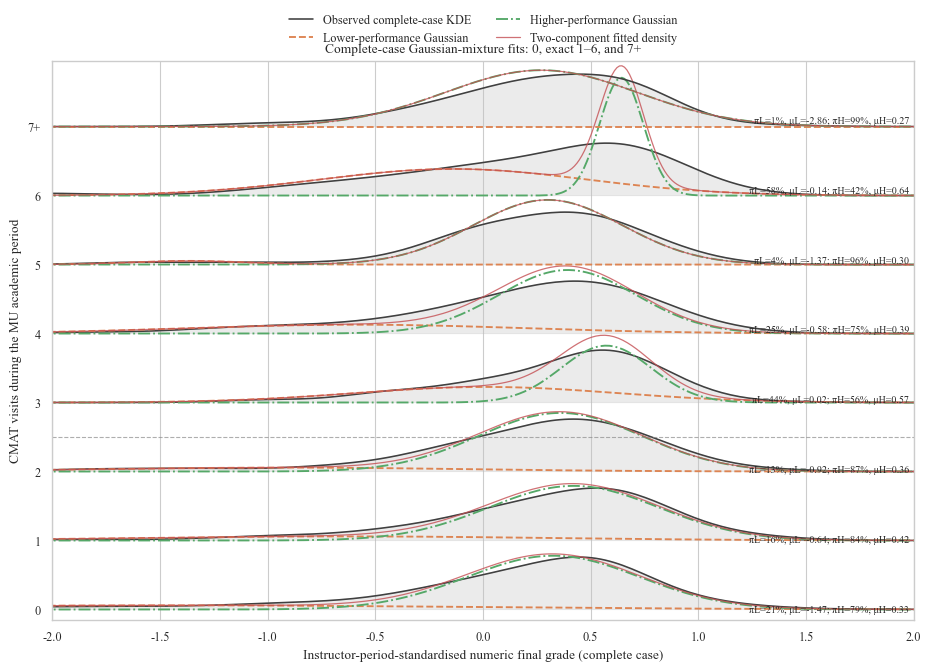

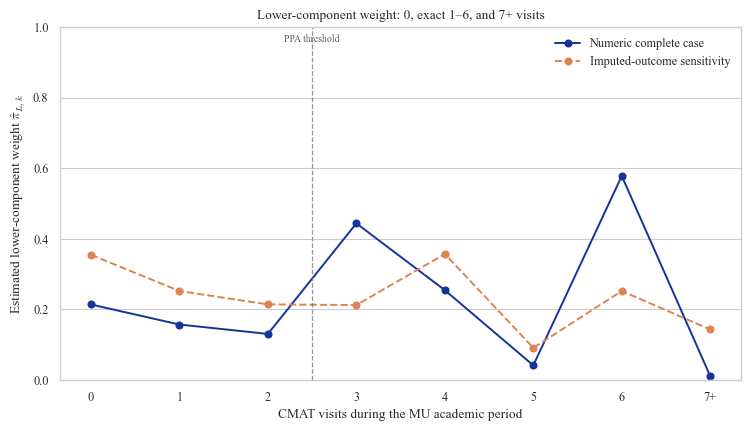

In [47]:
# Complete-case Gaussian-mixture ridgeline and lower-component weight comparison.
render_paper_figure(paper21_figures.plot_complete_case_gmm_ridgeline)
render_paper_figure(paper21_figures.plot_lower_component_weight)


## 12. What is inside the lower imputed component?

The mixture is not converted into hard student labels. Instead, posterior component responsibilities are aggregated softly by the observed final state. This preserves uncertainty about component membership.

Among CMAT users, the lower imputed component is strongly enriched in administrative outcomes, especially BV, whereas the higher component is overwhelmingly PASS. This links the distributional result to the separate academic-management result without claiming that the lower component is a psychological student type.


### 12.1 Soft outcome-state composition using posterior responsibilities

#### What this block does

This block asks which observed academic-result states contribute probability mass to each fitted imputed-outcome component without assigning students deterministically to one component.

#### What is happening mathematically / technically?

After EM, each observation has posterior responsibilities

$$
r_{iL}=P(C_i=L\mid z_i),
\qquad
r_{iH}=P(C_i=H\mid z_i),
\qquad
r_{iL}+r_{iH}=1.
$$

A hard classifier would replace this vector with $\arg\max_k r_{ik}$, discarding uncertainty. The paper instead uses soft expected counts. For component $k$ and observed academic state $s$,

$$
\widehat N_{ks}
=
\sum_{i=1}^{n}
r_{ik}\mathbf 1(S_i=s),
$$

$$
\widehat N_k
=
\sum_i r_{ik},
\qquad
\widehat P(S=s\mid C=k)
=
\frac{\widehat N_{ks}}{\widehat N_k}.
$$

Therefore a student with $(r_{iL},r_{iH})=(0.60,0.40)$ contributes 0.60 expected observations to the lower component and 0.40 to the higher component. No row-level component label is required or saved.

This calculation describes the **composition implied by the fitted density model**. It does not convert the GMM into an observed latent-class outcome model.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

After fitting the mixture, observation $i$ has posterior component probabilities. For example,

$$
(r_{iL},r_{iH})
=
(0.60,0.40).
$$

A hard assignment would put this observation entirely into one component and discard the uncertainty. Soft composition instead counts it fractionally. For component $k$ and observed outcome state $s$,

$$
\widehat N_{ks}
=
\sum_i
r_{ik}I(S_i=s).
$$

Thus the example observation contributes 0.60 expected observations to the lower component and 0.40 to the higher component. The total expected size of component $k$ is

$$
\widehat N_k
=
\sum_i r_{ik},
$$

so the estimated state share is $\widehat N_{ks}/\widehat N_k$. This is an expectation calculation using probabilistic membership, not a deterministic classification of students.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

This calculation assumes the fitted two-component model is worth summarizing; if the mixture itself is unstable, its responsibility-based composition is also unstable. Responsibilities are posterior probabilities conditional on the fitted model and its parameters, not externally validated probabilities that a student belongs to a real latent class.

We choose soft rather than hard assignment because it preserves uncertainty. A student with responsibilities 0.55 and 0.45 contributes fractionally to both components rather than being declared a member of one component based on a narrow threshold. The consequence is that “expected counts” may be non-integers and should be read as model-based decompositions of probability mass.

</div>


In [48]:
component_composition_tables = {
    "Complete-case soft component composition":
        pd.read_csv(TABLES_DIR / "40_complete_case_gmm_soft_component_composition.csv"),
    "Imputed soft component composition":
        pd.read_csv(TABLES_DIR / "44_imputed_gmm_soft_component_composition.csv"),
    "Exact 6 / 7+ complete-case soft component composition":
        pd.read_csv(TABLES_DIR / "56_sensitivity_6_7plus_complete_case_gmm_soft_component_composition.csv"),
    "Exact 6 / 7+ imputed soft component composition":
        pd.read_csv(TABLES_DIR / "60_sensitivity_6_7plus_imputed_gmm_soft_component_composition.csv"),
}

if SUMMARY:
    for title, table in component_composition_tables.items():
        display(Markdown(f"#### {title} — largest state share per fitted component"))
        display(summarize_component_composition(table))
else:
    for title, table in component_composition_tables.items():
        display(Markdown(f"#### {title}"))
        display(table)

imputed_composition = component_composition_tables["Imputed soft component composition"]
imputed_tail_composition = component_composition_tables[
    "Exact 6 / 7+ imputed soft component composition"
]



#### Complete-case soft component composition — largest state share per fitted component

,group,component,largest_state_share,largest_state_share_value,component_expected_n
0,0,higher_performance,pass,0.9767,3511.0755
1,0,lower_performance,numeric_nonpass,0.5221,955.9245
2,1,higher_performance,pass,0.9955,365.1070
3,1,lower_performance,pass,0.8033,67.8930
4,2,higher_performance,pass,0.9881,181.7988
5,2,lower_performance,pass,0.6751,27.2012
6,3,higher_performance,pass,1.0000,80.0657
7,3,lower_performance,pass,0.9218,63.9343
8,4,higher_performance,pass,1.0000,62.6133
9,4,lower_performance,pass,0.9532,21.3867


#### Imputed soft component composition — largest state share per fitted component

,group,component,largest_state_share,largest_state_share_value,component_expected_n
0,0,higher_performance,pass,0.9572,3479.0139
1,0,lower_performance,pass,0.2920,1913.9861
2,1,higher_performance,pass,0.9744,386.6583
3,1,lower_performance,BV,0.5117,130.3417
4,2,higher_performance,pass,0.9549,192.5990
5,2,lower_performance,BV,0.5049,52.4010
6,3,higher_performance,pass,0.9690,133.9061
7,3,lower_performance,BV,0.6134,36.0939
8,4,higher_performance,pass,0.9850,61.7167
9,4,lower_performance,pass,0.6479,34.2833


#### Exact 6 / 7+ complete-case soft component composition — largest state share per fitted component

,group,component,largest_state_share,largest_state_share_value,component_expected_n
0,6,higher_performance,pass,1.0000,18.1335
1,6,lower_performance,pass,0.9196,24.8665
2,7+,higher_performance,pass,0.9783,92.0000
3,7+,lower_performance,numeric_nonpass,1.0000,1.0000


#### Exact 6 / 7+ imputed soft component composition — largest state share per fitted component

,group,component,largest_state_share,largest_state_share_value,component_expected_n
0,6,higher_performance,pass,0.9752,37.4090
1,6,lower_performance,BV,0.5535,12.5910
2,7+,higher_performance,pass,0.9843,86.5324
3,7+,lower_performance,BV,0.4612,14.4676


Aggregated across positive-attendance groups in the manuscript's validated analysis, the lower imputed component is approximately 55.5% administrative outcomes, including about 49.5% BV, whereas the higher component is approximately 97% PASS.

The appropriate interpretation is therefore:

> the completed outcome contains a lower distributional component strongly enriched in adverse administrative endings, especially BV.

The inappropriate interpretation would be that the model has discovered fixed categories such as “good students” and “bad students.”


## 13. Instructor-level clustering sensitivity

The primary specification clusters by instructor-period because that is also the fixed-effect grading context. As a dependence sensitivity, the paper re-clusters by instructor while retaining instructor-period fixed effects.

The broad zero-versus-positive benchmark remains nearly unchanged. Positive-frequency omnibus tests become somewhat more suggestive, but the result still does not become a clean adjacent visit-by-visit staircase.


### 13.1 Sensitivity to clustering at the instructor level

#### What this block does

This block refits the robustness specification directly from the analytical cohort, retaining the instructor-period fixed effects while changing the cluster identifier from instructor-period to instructor. It displays the full coefficient tables, all pairwise contrasts, omnibus tests, and the broad 0-vs-1+ benchmark under instructor-level clustering.

#### What is happening mathematically / technically?

The coefficient vector $\hat\beta$ is unchanged in principle because the regression design matrix and OLS objective are unchanged. What changes is the partition used in the sandwich “meat.”

Primary covariance:

$$
\widehat V_{\text{classroom}}
\propto
(X'X)^{-1}
\left[
\sum_{c}
X_c'\hat u_c\hat u_c'X_c
\right]
(X'X)^{-1}.
$$

Instructor sensitivity:

$$
\widehat V_{\text{prof}}
\propto
(X'X)^{-1}
\left[
\sum_{p}
X_p'\hat u_p\hat u_p'X_p
\right]
(X'X)^{-1},
$$

where $p$ pools all instructor-period observations belonging to the same instructor.

The second specification therefore allows arbitrary residual correlation across different academic periods taught by the same professor. It is a dependence-structure sensitivity, not a new confounding adjustment and not a different exposure estimand.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

The OLS point estimate depends only on $X$ and $Y$,

$$
\hat\beta
=
(X^\top X)^{-1}X^\top Y,
$$

so changing only the clustering rule leaves $\hat\beta$ unchanged. What changes is the estimated covariance of $\hat\beta$.

With instructor-period clusters, the central part of the sandwich is

$$
\sum_c
X_c^\top
\hat u_c\hat u_c^\top
X_c.
$$

With instructor clusters, all periods taught by the same professor are pooled before forming the outer product,

$$
\sum_p
X_p^\top
\hat u_p\hat u_p^\top
X_p.
$$

The second specification therefore permits residual dependence across different periods taught by the same professor. Intuitively, treating more observations as potentially dependent reduces the amount of information regarded as independent, which can enlarge standard errors even though the coefficients themselves are identical. This block asks whether the conclusions depend strongly on the chosen boundary of an “approximately independent” cluster.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The primary covariance treats instructor-period clusters as approximately independent; the sensitivity instead treats all observations from the same instructor across periods as one dependence cluster. Both allow arbitrary heteroskedasticity and arbitrary residual correlation within their chosen clusters. Neither permits unrestricted correlation across different instructors.

We choose instructor-period clustering as primary because it matches the grading-context fixed effect, while instructor-level clustering is a stricter dependence sensitivity that allows correlation to persist across periods taught by the same professor. The coefficient estimates remain the same because $X$ and $Y$ are unchanged; only the estimated covariance changes. If conclusions weaken substantially under instructor clustering, the correct implication is that inference is sensitive to the assumed dependence boundary, not that one set of coefficients is “truer.”

</div>


In [49]:
users_primary = mu.loc[mu["VISITS_CMAT_PERIOD"].gt(0)].copy()
users_primary = add_topcoded_visit_group(
    users_primary,
    visits_col="VISITS_CMAT_PERIOD",
    top_exact=5,
    include_zero=False,
    output_col="P21_GROUP_PRIMARY",
)
PRIMARY_USER_ORDER = ["1", "2", "3", "4", "5", "6+"]

z_prof_pair, z_prof_omnibus, z_prof_info = fixed_effect_group_comparisons(
    users_primary,
    group_col="P21_GROUP_PRIMARY",
    group_order=PRIMARY_USER_ORDER,
    outcome_col="Z_GRADE_PRIMARY",
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLAVEPROFESOR",
    categorical_covariates=["CLAVECARRERA"],
    multiplicity_method="holm",
)
pass_prof_pair, pass_prof_omnibus, pass_prof_info = fixed_effect_group_comparisons(
    users_primary,
    group_col="P21_GROUP_PRIMARY",
    group_order=PRIMARY_USER_ORDER,
    outcome_col="PASS",
    fixed_effect_col="CLASSROOM_ID",
    cluster_col="CLAVEPROFESOR",
    categorical_covariates=["CLAVECARRERA"],
    multiplicity_method="holm",
)

z_prof_model, z_prof_data, z_prof_formula = fit_full_ols_group_model(
    users_primary,
    group_col="P21_GROUP_PRIMARY",
    group_order=PRIMARY_USER_ORDER,
    outcome_col="Z_GRADE_PRIMARY",
    cluster_col="CLAVEPROFESOR",
)
pass_prof_model, pass_prof_data, pass_prof_formula = fit_full_ols_group_model(
    users_primary,
    group_col="P21_GROUP_PRIMARY",
    group_order=PRIMARY_USER_ORDER,
    outcome_col="PASS",
    cluster_col="CLAVEPROFESOR",
)

if SUMMARY:
    display_full_model(
        z_prof_model, z_prof_data, z_prof_formula,
        cluster_col="CLAVEPROFESOR",
        title="Instructor-cluster sensitivity: continuous outcome",
    )
    display_full_model(
        pass_prof_model, pass_prof_data, pass_prof_formula,
        cluster_col="CLAVEPROFESOR",
        title="Instructor-cluster sensitivity: PASS LPM",
    )
else:
    display_full_model(
        z_prof_model, z_prof_data, z_prof_formula,
        cluster_col="CLAVEPROFESOR",
        title="Instructor-cluster sensitivity: continuous outcome",
    )
    display(Markdown("#### Instructor-cluster continuous outcome — all pairwise contrasts"))
    display(z_prof_pair)
    display(Markdown("#### Instructor-cluster continuous outcome — omnibus"))
    display(z_prof_omnibus)
    display(Markdown("#### Instructor-cluster continuous outcome — model information"))
    display(z_prof_info)

    display_full_model(
        pass_prof_model, pass_prof_data, pass_prof_formula,
        cluster_col="CLAVEPROFESOR",
        title="Instructor-cluster sensitivity: PASS LPM",
    )
    display(Markdown("#### Instructor-cluster PASS — all pairwise contrasts"))
    display(pass_prof_pair)
    display(Markdown("#### Instructor-cluster PASS — omnibus"))
    display(pass_prof_omnibus)
    display(Markdown("#### Instructor-cluster PASS — model information"))
    display(pass_prof_info)

instructor_benchmark_data = mu.copy()
instructor_benchmark_data["ATTENDANCE_BINARY"] = np.where(
    instructor_benchmark_data["VISITS_CMAT_PERIOD"].gt(0), "1+", "0"
)

instructor_benchmark_rows = []
for outcome_col in ["Z_GRADE_PRIMARY", "PASS"]:
    pairwise, omnibus, info = fixed_effect_group_comparisons(
        instructor_benchmark_data,
        group_col="ATTENDANCE_BINARY",
        group_order=["0", "1+"],
        outcome_col=outcome_col,
        fixed_effect_col="CLASSROOM_ID",
        cluster_col="CLAVEPROFESOR",
        categorical_covariates=["CLAVECARRERA"],
        multiplicity_method="holm",
    )
    row = pairwise.iloc[0]
    instructor_benchmark_rows.append({
        "outcome": outcome_col,
        "1+ minus 0": -float(row["estimate_group1_minus_group2"]),
        "cluster_robust_se": float(row["cluster_robust_se"]),
        "ci95_low": -float(row["ci_high"]),
        "ci95_high": -float(row["ci_low"]),
        "p_value": float(row["p_raw"]),
        "N": int(row["n"]),
        "n_instructors": int(info.loc[0, "n_clusters"]),
    })

instructor_benchmark = pd.DataFrame(instructor_benchmark_rows)
instructor_omnibus = pd.concat([
    z_prof_omnibus.assign(outcome="Z_GRADE_PRIMARY"),
    pass_prof_omnibus.assign(outcome="PASS"),
], ignore_index=True)

display(Markdown("#### Instructor-cluster broad 0 vs 1+ benchmark"))
display(instructor_benchmark)
display(Markdown("#### Instructor-cluster user-frequency omnibus tests"))
display(instructor_omnibus)



#### Instructor-cluster sensitivity: continuous outcome — compact model summary

,N,covariance_type,cluster_variable,n_clusters,R_squared,adjusted_R_squared,AIC
0,1234,cluster,CLAVEPROFESOR,51,0.2198,0.0466,3041.1373


,term,estimate,cluster_robust_se,statistic,p_value,ci95_low,ci95_high
0,Intercept,0.1755,0.1623,1.0810,0.2797,-0.1427,0.4936
1,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.0600,0.0653,0.9175,0.3589,-0.0681,0.1880
2,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.0447,0.0799,0.5595,0.5758,-0.1119,0.2013
3,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.0675,0.1459,0.4630,0.6433,-0.2184,0.3535
4,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.2062,0.1311,1.5729,0.1157,-0.0508,0.4632
5,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.2334,0.0901,2.5906,0.0096,0.0568,0.4100


#### Instructor-cluster sensitivity: PASS LPM — compact model summary

,N,covariance_type,cluster_variable,n_clusters,R_squared,adjusted_R_squared,AIC
0,1234,cluster,CLAVEPROFESOR,51,0.2705,0.1085,1179.2841


,term,estimate,cluster_robust_se,statistic,p_value,ci95_low,ci95_high
0,Intercept,0.9741,0.0616,15.8143,0.0000,0.8533,1.0948
1,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.0310,0.0291,1.0630,0.2878,-0.0261,0.0880
2,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",-0.0072,0.0379,-0.1893,0.8499,-0.0815,0.0671
3,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.0835,0.0613,1.3621,0.1732,-0.0366,0.2036
4,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.0689,0.0539,1.2774,0.2015,-0.0368,0.1746
5,"C(P21_GROUP_PRIMARY, Treatment(reference='1'))...",0.1201,0.0395,3.0375,0.0024,0.0426,0.1976


#### Instructor-cluster broad 0 vs 1+ benchmark

,outcome,1+ minus 0,cluster_robust_se,ci95_low,ci95_high,p_value,N,n_instructors
0,Z_GRADE_PRIMARY,0.3612,0.0286,0.3051,0.4173,0.0000,6627,53
1,PASS,0.1529,0.0126,0.1282,0.1776,0.0000,6627,53


#### Instructor-cluster user-frequency omnibus tests

,null_hypothesis,test_statistic,df_num,p_value,n,n_clusters,outcome
0,equal adjusted outcomes across listed groups,2.4293,5,0.0477,1234,51,Z_GRADE_PRIMARY
1,equal adjusted outcomes across listed groups,2.3403,5,0.0551,1234,51,PASS


## 14. Discussion

The results support a layered interpretation of CMAT attendance.

First, the strongest and most stable empirical separation is between **zero attendance and any recorded attendance**. Every positive-frequency group lies above the zero group on adjusted standardized performance, and the broad benchmark is also large for PASS.

Second, frequency among users is not a smooth dose-response curve. The PPA-compatible first three visits are similar to one another, and the third visit does not coincide with an academic discontinuity. Later descriptive changes, including four-to-five and six-to-7+, are visible but imprecise.

Third, the 7+ group is a meaningful high-frequency profile because it has the highest observed mean and pass rate and because its adjusted PASS probability exceeds the one-visit group after multiplicity correction. This is evidence of a distinctive observed profile, not proof that the seventh visit itself causes the difference.

Fourth, adverse outcomes differ in **type**, not only in frequency. CMAT users who do not pass are relatively less likely to finish with a numeric failing grade and relatively more likely to have BV, while RT does not show the same adjusted contrast. This pattern is compatible with broader academic engagement or institutional navigation, but those mechanisms are not directly measured.

Finally, the distributional analysis shows why observed numeric grades and the imputed completed outcome must both be reported. Administrative outcomes materially sharpen the lower component of the imputed distribution. The stronger bimodality in the completed outcome therefore cannot be interpreted as a universal two-type structure among students.


## 15. Limits and identification

The principal limitation is self-selection. Students are not randomly assigned to CMAT, and visit frequency can be related to prior preparation, academic difficulty, motivation, schedule flexibility, persistence, advice seeking, and other unmeasured characteristics.

Timing is also endogenous. Students may attend because difficulties emerge, return because the service is useful, stop attending because they no longer need help, or have fewer opportunities to accumulate visits because they withdraw earlier.

PPA further complicates the behavioral meaning of the first three visits because the records do not identify which visits were specifically motivated by participation credit. Thus the third visit is not a valid regression-discontinuity cutoff or instrument in the present data.

The high-frequency cells are small, especially exact six and the exact counts above six before pooling, so uncertainty is visibly wider in the upper tail. Mixture components are density approximations rather than identified latent classes, and the numerical values assigned to BV/RT/BA are unobserved imputations whose role must remain transparent.

Consequently, the target estimand of the present notebook is descriptive/associational:

$$
E[Y\mid K=k, X] - E[Y\mid K=j, X],
$$

after the documented adjustment, rather than the causal potential-outcome contrast

$$
E[Y(k)-Y(j)].
$$


## 16. Conclusion

The full attendance profile contains substantially more structure than a simple user/non-user indicator, but it does not support a monotone dose-response interpretation.

The most robust result is the large **0 versus 1+** separation. Within positive attendance, the first one to three visits are difficult to interpret as purely voluntary because of PPA, and there is no observable break exactly at the third visit. The 7+ group is the clearest high-frequency profile, especially for PASS, while adjacent high-frequency contrasts remain imprecise.

The distributional extension adds an important second result: once administrative outcomes are incorporated into the completed continuous outcome, a lower performance component becomes much clearer and is strongly enriched in BV and other adverse endings. Observed numeric grades alone provide a more heterogeneous and less universally bimodal picture.

The defensible synthesis is therefore:

$$
\boxed{
\text{CMAT frequency is not a simple treatment dose;}
\quad
0\text{ vs }1+\text{ dominates,}
\quad
7+\text{ is distinctive,}
\quad
\text{and adverse-outcome composition matters.}
}
$$


## 17. Full canonical regeneration

All seven manuscript figures above are already **constructed and rendered inline** by the notebook. The cell below is separate: it is only for regenerating the repository's canonical aggregate CSV tables and saved vector-PDF artifacts from the controlled pseudonymized inputs.

It is intentionally not executed automatically because the full mixture bootstrap and repeated cross-validation are computationally expensive.


### 17.1 Full end-to-end regeneration

#### What this block does

When enabled, this block calls the repository build orchestration to regenerate the complete aggregate-table family and all publication figures from the controlled pseudonymized inputs.

#### What is happening mathematically / technically?

The dependency graph is

$$
\text{controlled row-level data}
\longrightarrow
\begin{cases}
\text{support audit}\\
\text{OLS/LPM/logit outcomes}\\
\text{GMM/skew-normal/bootstrap/CV}
\end{cases}
\longrightarrow
\text{aggregate CSVs}
\longrightarrow
\text{publication figures}.
$$

The point of this block is not to introduce another estimator. It verifies that the notebook's displayed results can be regenerated by the same canonical runners that produce the manuscript artifacts.

The expensive step is the repeated refitting of mixture models inside the parametric bootstraps and cross-validation folds. That is why the switch remains off during ordinary interactive reading.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

This cell is function composition rather than another statistical estimator. The controlled row-level files are transformed into an analytical cohort; the cohort is transformed into model estimates and aggregate tables; those outputs are transformed into figures and manuscript artifacts:

$$
\text{controlled data}
\longrightarrow
\text{analysis cohort}
\longrightarrow
\text{estimates and tables}
\longrightarrow
\text{figures and paper}.
$$

A reproducible build means that every arrow is implemented by versioned code rather than by manual editing. Running the orchestration from the beginning is therefore a consistency check that the notebook, tables, figures, and manuscript can all be regenerated from the same inputs and analysis definitions.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

The build assumes that the versioned controlled inputs, grouping specification, and analysis code are the canonical study definition. The expensive mixture stage is intentionally not rerun on every ordinary notebook execution because repeated EM, bootstrap, and CV dominate runtime. The canonical paper build fixes those heavy settings explicitly—199 GMM bootstrap replicates, 199 skew-normal bootstrap replicates, 5 CV folds, and 10 repeats—so regeneration does not silently depend on command-line defaults. The consequence is that a full forced rebuild should reproduce the validated aggregate tables up to deterministic numerical behavior under the fixed seeds.

</div>


In [50]:
RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    subprocess.run(
        [sys.executable, str(PAPER_DIR / "paper_build.py"), "--tables", "--figures"],
        cwd=REPO_ROOT,
        check=True,
    )
else:
    print(
        "Full pipeline not run. Set RUN_FULL_PIPELINE=True to regenerate all canonical "
        "aggregate tables and publication figures from the controlled pseudonymized inputs."
    )


Full pipeline not run. Set RUN_FULL_PIPELINE=True to regenerate all canonical aggregate tables and publication figures from the controlled pseudonymized inputs.


## 18. Provenance and source files

The notebook is a presentation layer over the same analysis stack as the manuscript. For audit or modification, the canonical sources are:

- `paper/sections/01.tex`–`04.tex`: manuscript text;
- `paper/docs/analysis/ANALYSIS_PLAN.md`: analysis contract;
- `paper/docs/analysis/VISIT_GROUPING_DECISION.md`: outcome-blind grouping history;
- `paper/docs/results/PRELIMINARY_RESULTS.md`: verified result summary;
- `paper/docs/results/MIXTURE_ANALYSIS_RESULTS.md`: mixture-model validation and interpretation;
- `paper/docs/interpretation/ACADEMIC_MANAGEMENT_HYPOTHESIS.md`: mechanism guardrails;
- `code/run_paper21_outcomes.py`: main outcome analysis;
- `code/run_paper21_mixture.py`: numeric-failure and mixture analysis;
- `code/figures_paper21.py`: publication figures;
- `paper/references.bib`: bibliography.

The notebook should be updated when the canonical manuscript or analysis changes; scientific methods should continue to live in `cmat_analysis`, not be forked into notebook-only helper implementations.


### 18.1 Exact manuscript bibliography

#### What this block does

This final code block prints the BibTeX database used by the manuscript so the computational document and the paper share one reference source.

#### What is happening mathematically / technically?

There is no statistical operation here. The technical purpose is **single-source provenance**: the notebook reads `paper/references.bib` directly rather than maintaining a copied citation list. Consequently, changes to the manuscript bibliography are visible here without synchronizing a second bibliographic database.

<div style="font-size: 0.7em; color: gray; line-height: 1.5;">

There is no estimator in this block. Its role is provenance: the notebook reads the same BibTeX database used by the manuscript, so citation metadata has one canonical source. This prevents the computational document and the paper from silently diverging because references were copied, reformatted, or corrected independently in two places.
</div>

<div style="font-size: 0.76em; color: #1b0d61; line-height: 1.5; border-left: 4px solid #1b0d61; padding: 0.7em 1em; background-color: #f6f5ff;">
<strong>Assumptions, consequences, and why this choice.</strong><br>

There is no statistical assumption here. The design choice is to use one BibTeX file as the single source of citation metadata for both the executable notebook and manuscript. This prevents literature references from diverging across outputs, but it does not itself validate the substantive claims made from those sources.

</div>


In [51]:
# Optional: show the exact bibliography used by the manuscript.
references = (PAPER_DIR / "references.bib").read_text(encoding="utf-8")

if SUMMARY:
    n_entries = sum(
        1 for line in references.splitlines()
        if line.lstrip().startswith("@")
    )
    print(f"Bibliography loaded: {n_entries} BibTeX entries from {PAPER_DIR / 'references.bib'}")
    print("Set SUMMARY=False to print the complete BibTeX database.")
else:
    print(references)


Bibliography loaded: 14 BibTeX entries from /Users/heri/git/CMAT/CMAT-research/paper/references.bib
Set SUMMARY=False to print the complete BibTeX database.
